<a href="https://colab.research.google.com/github/Mirza-PU/Space-time-curvature-/blob/main/General_relativity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================
# GR-SPACETIME DATASET V4
# PHYSICS-INFORMED, LEAKAGE-FREE CLASSIFICATION DATASET
# ============================================================
#
# Purpose:
#   Generate a balanced synthetic dataset for classification of:
#
#   0 = Minkowski
#   1 = Schwarzschild
#   2 = Kerr
#   3 = Reissner-Nordstrom
#   4 = Kerr-Newman
#   5 = de_Sitter
#   6 = Anti_de_Sitter
#   7 = FLRW
#
# Main improvements over V3:
#
#   1. Physical parameters retained separately
#   2. More independent physics-inspired descriptors
#   3. Charge-sensitive descriptors
#   4. Rotation-sensitive descriptors
#   5. Pseudoscalar / parity-sensitive descriptors
#   6. Electromagnetic-inspired descriptors
#   7. Mixed curvature-EM descriptors
#   8. Balanced class generation
#   9. Controlled observational noise
#  10. No "spacetime" input feature
#  11. No target leakage
#
# IMPORTANT:
# This is a synthetic benchmark generator.
# Exact GR curvature invariants should be replaced by
# metric-derived symbolic/numerical expressions if exact
# physical validation is required.
# ============================================================

import os
import time
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42
rng = np.random.default_rng(SEED)

# ------------------------------------------------------------
# Dataset size
# ------------------------------------------------------------

N_TOTAL = 2_000_000

N_CLASSES = 8

SAMPLES_PER_CLASS = N_TOTAL // N_CLASSES

# ------------------------------------------------------------
# Noise
# ------------------------------------------------------------

USE_NOISE = True

# Small measurement / numerical perturbation.
# Keep this relatively small so that the underlying
# physical structure remains identifiable.
NOISE_LEVEL = 0.005

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

BASE_DIR = "/content/GR_Spacetime_Dataset_V4"

os.makedirs(BASE_DIR, exist_ok=True)

FULL_FILE = os.path.join(
    BASE_DIR,
    "GR_Spacetime_V4_FULL.csv"
)

PARAM_FILE = os.path.join(
    BASE_DIR,
    "GR_Spacetime_V4_PARAMETERS.csv"
)

FEATURE_FILE = os.path.join(
    BASE_DIR,
    "GR_Spacetime_V4_FEATURES.csv"
)

TRAIN_FILE = os.path.join(
    BASE_DIR,
    "GR_Spacetime_V4_TRAIN.csv"
)

VAL_FILE = os.path.join(
    BASE_DIR,
    "GR_Spacetime_V4_VAL.csv"
)

TEST_FILE = os.path.join(
    BASE_DIR,
    "GR_Spacetime_V4_TEST.csv"
)

# ============================================================
# 2. CLASS DEFINITIONS
# ============================================================

CLASS_NAMES = [
    "Minkowski",
    "Schwarzschild",
    "Kerr",
    "Reissner-Nordstrom",
    "Kerr-Newman",
    "de_Sitter",
    "Anti_de_Sitter",
    "FLRW"
]

CLASS_IDS = {
    name: i
    for i, name in enumerate(CLASS_NAMES)
}

print("=" * 80)
print("GR-SPACETIME V4 DATASET GENERATOR")
print("=" * 80)

print(f"Total samples       : {N_TOTAL:,}")
print(f"Samples per class   : {SAMPLES_PER_CLASS:,}")
print(f"Number of classes   : {N_CLASSES}")
print(f"Noise level         : {NOISE_LEVEL}")
print(f"Output directory    : {BASE_DIR}")

# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

EPS = 1e-12


def safe_log_abs(x):
    """
    Signed logarithmic transformation.
    Prevents log(0) and retains sign information.
    """
    return np.sign(x) * np.log1p(np.abs(x))


def add_noise(x, level=NOISE_LEVEL):
    """
    Multiplicative Gaussian perturbation.
    """
    if not USE_NOISE:
        return x

    scale = np.maximum(np.abs(x), 1e-8)

    noise = rng.normal(
        loc=0.0,
        scale=level,
        size=x.shape
    )

    return x + noise * scale


def clip_parameter(x, low, high):
    return np.clip(x, low, high)


# ============================================================
# 4. PHYSICAL PARAMETER GENERATION
# ============================================================

def generate_parameters(class_name, n):
    """
    Generate physically motivated synthetic parameters.

    These parameters are NOT passed directly to the classifier.
    They are retained for scientific analysis.
    """

    # --------------------------------------------------------
    # Common parameters
    # --------------------------------------------------------

    M = rng.uniform(
        0.5,
        5.0,
        n
    )

    r = rng.uniform(
        2.0,
        30.0,
        n
    )

    theta = rng.uniform(
        0.05,
        np.pi - 0.05,
        n
    )

    # Spin
    a = np.zeros(n)

    # Charge
    Q = np.zeros(n)

    # Cosmological constant
    Lambda = np.zeros(n)

    # FLRW parameters
    H = np.zeros(n)
    k = np.zeros(n)

    # --------------------------------------------------------
    # Minkowski
    # --------------------------------------------------------

    if class_name == "Minkowski":

        M[:] = 0.0
        r = rng.uniform(
            2.0,
            30.0,
            n
        )

    # --------------------------------------------------------
    # Schwarzschild
    # --------------------------------------------------------

    elif class_name == "Schwarzschild":

        a[:] = 0.0
        Q[:] = 0.0

        r_min = 2.5 * M

        r = np.maximum(
            r,
            r_min
        )

    # --------------------------------------------------------
    # Kerr
    # --------------------------------------------------------

    elif class_name == "Kerr":

        a = rng.uniform(
            -0.90,
            0.90,
            n
        ) * M

        Q[:] = 0.0

        r_min = (
            M
            + np.sqrt(
                np.maximum(
                    M**2 - a**2,
                    EPS
                )
            )
        )

        r = np.maximum(
            r,
            1.2 * r_min
        )

    # --------------------------------------------------------
    # Reissner-Nordstrom
    # --------------------------------------------------------

    elif class_name == "Reissner-Nordstrom":

        a[:] = 0.0

        Q = rng.uniform(
            -0.85,
            0.85,
            n
        ) * M

        horizon_term = np.sqrt(
            np.maximum(
                M**2 - Q**2,
                EPS
            )
        )

        r_plus = M + horizon_term

        r = np.maximum(
            r,
            1.2 * r_plus
        )

    # --------------------------------------------------------
    # Kerr-Newman
    # --------------------------------------------------------

    elif class_name == "Kerr-Newman":

        a = rng.uniform(
            -0.85,
            0.85,
            n
        ) * M

        # Ensure charge and rotation are simultaneously nonzero
        Q = rng.uniform(
            -0.75,
            0.75,
            n
        ) * M

        discriminant = (
            M**2
            - a**2
            - Q**2
        )

        # Keep sub-extremal configurations
        valid = discriminant > 0

        while not np.all(valid):

            idx = np.where(~valid)[0]

            a[idx] = rng.uniform(
                -0.75,
                0.75,
                len(idx)
            ) * M[idx]

            Q[idx] = rng.uniform(
                -0.65,
                0.65,
                len(idx)
            ) * M[idx]

            discriminant[idx] = (
                M[idx]**2
                - a[idx]**2
                - Q[idx]**2
            )

            valid = discriminant > 0

        r_plus = (
            M
            + np.sqrt(
                np.maximum(
                    discriminant,
                    EPS
                )
            )
        )

        r = np.maximum(
            r,
            1.2 * r_plus
        )

    # --------------------------------------------------------
    # de Sitter
    # --------------------------------------------------------

    elif class_name == "de_Sitter":

        M[:] = 0.0
        a[:] = 0.0
        Q[:] = 0.0

        Lambda = rng.uniform(
            0.005,
            0.20,
            n
        )

        H = np.sqrt(
            Lambda / 3.0
        )

        r = rng.uniform(
            0.05,
            0.8 / np.sqrt(Lambda),
            n
        )

    # --------------------------------------------------------
    # Anti-de Sitter
    # --------------------------------------------------------

    elif class_name == "Anti_de_Sitter":

        M[:] = 0.0
        a[:] = 0.0
        Q[:] = 0.0

        Lambda = -rng.uniform(
            0.005,
            0.20,
            n
        )

        H = np.sqrt(
            np.abs(Lambda) / 3.0
        )

        r = rng.uniform(
            0.5,
            20.0,
            n
        )

    # --------------------------------------------------------
    # FLRW
    # --------------------------------------------------------

    elif class_name == "FLRW":

        M[:] = 0.0
        a[:] = 0.0
        Q[:] = 0.0

        H = rng.uniform(
            0.01,
            0.30,
            n
        )

        k_choices = np.array([
            -1.0,
            0.0,
            1.0
        ])

        k = rng.choice(
            k_choices,
            size=n
        )

        Lambda = rng.uniform(
            -0.05,
            0.05,
            n
        )

        r = rng.uniform(
            0.5,
            20.0,
            n
        )

    else:
        raise ValueError(
            f"Unknown class: {class_name}"
        )

    return {
        "M": M,
        "Q": Q,
        "a": a,
        "r": r,
        "theta": theta,
        "Lambda": Lambda,
        "H": H,
        "k": k
    }


# ============================================================
# 5. PHYSICS-INSPIRED FEATURE GENERATION
# ============================================================

def generate_features(
    class_name,
    p
):
    """
    Generate physics-inspired scalar descriptors.

    IMPORTANT:
    These are synthetic benchmark descriptors.
    They are not claimed to be exact closed-form
    curvature invariants for every spacetime.
    """

    M = p["M"]
    Q = p["Q"]
    a = p["a"]
    r = p["r"]
    theta = p["theta"]
    Lambda = p["Lambda"]
    H = p["H"]
    k = p["k"]

    cos_theta = np.cos(theta)

    # --------------------------------------------------------
    # Basic radial scales
    # --------------------------------------------------------

    inv_r = 1.0 / np.maximum(
        r,
        EPS
    )

    M_r3 = (
        M
        * inv_r**3
    )

    M2_r6 = (
        M**2
        * inv_r**6
    )

    Q2_r4 = (
        Q**2
        * inv_r**4
    )

    Q2_r6 = (
        Q**2
        * inv_r**6
    )

    a2_r2 = (
        a**2
        * inv_r**2
    )

    aM_r4 = (
        a
        * M
        * inv_r**4
    )

    # ========================================================
    # Base curvature-inspired quantities
    # ========================================================

    if class_name == "Minkowski":

        R = np.zeros_like(r)

        Ricci2 = np.zeros_like(r)

        K = np.zeros_like(r)

        Weyl2 = np.zeros_like(r)

        Weyl4 = np.zeros_like(r)

    elif class_name == "Schwarzschild":

        R = np.zeros_like(r)

        Ricci2 = np.zeros_like(r)

        K = 48.0 * M2_r6

        Weyl2 = 48.0 * M2_r6

        Weyl4 = (
            Weyl2**2
        )

    elif class_name == "Kerr":

        R = np.zeros_like(r)

        Ricci2 = np.zeros_like(r)

        K = (
            48.0
            * M2_r6
            * (
                1
                - 15 * a2_r2 * cos_theta**2
                + 15 * a2_r2**2 * cos_theta**4
                - a2_r2**3 * cos_theta**6
            )
        )

        Weyl2 = (
            48.0
            * M2_r6
            * (
                1
                - 6 * a2_r2 * cos_theta**2
                + a2_r2**2 * cos_theta**4
            )
        )

        Weyl4 = Weyl2**2

    elif class_name == "Reissner-Nordstrom":

        R = np.zeros_like(r)

        Ricci2 = (
            4.0
            * Q2_r4
            * inv_r**0
        )

        K = (
            48.0 * M2_r6
            - 96.0 * M * Q**2 * inv_r**7
            + 56.0 * Q**4 * inv_r**8
        )

        Weyl2 = (
            48.0 * M2_r6
            - 96.0 * M * Q**2 * inv_r**7
            + 48.0 * Q**4 * inv_r**8
        )

        Weyl4 = Weyl2**2

    elif class_name == "Kerr-Newman":

        R = np.zeros_like(r)

        Ricci2 = (
            4.0
            * Q2_r4
            * (
                1
                + 3 * a2_r2 * cos_theta**2
            )
        )

        K = (
            48.0 * M2_r6
            + 56.0 * Q**4 * inv_r**8
            - 96.0 * M * Q**2 * inv_r**7
            + 12.0 * a2_r2 * M2_r6
        )

        Weyl2 = (
            48.0 * M2_r6
            - 96.0 * M * Q**2 * inv_r**7
            + 48.0 * Q**4 * inv_r**8
            + 24.0 * aM_r4**2
        )

        Weyl4 = Weyl2**2

    elif class_name == "de_Sitter":

        R = 4.0 * Lambda

        Ricci2 = (
            4.0 / 3.0
        ) * Lambda**2

        K = (
            8.0 / 3.0
        ) * Lambda**2

        Weyl2 = np.zeros_like(r)

        Weyl4 = np.zeros_like(r)

    elif class_name == "Anti_de_Sitter":

        R = 4.0 * Lambda

        Ricci2 = (
            4.0 / 3.0
        ) * Lambda**2

        K = (
            8.0 / 3.0
        ) * Lambda**2

        Weyl2 = np.zeros_like(r)

        Weyl4 = np.zeros_like(r)

    elif class_name == "FLRW":

        R = (
            6.0
            * (
                2.0 * H**2
                + k * inv_r**2
                + Lambda / 3.0
            )
        )

        Ricci2 = (
            12.0
            * (
                H**4
                + H**2 * np.abs(Lambda)
                + Lambda**2 / 9.0
            )
        )

        K = (
            12.0
            * (
                H**4
                + (
                    H**2
                    + k * inv_r**2
                )**2
            )
        )

        Weyl2 = np.zeros_like(r)

        Weyl4 = np.zeros_like(r)

    # ========================================================
    # Additional physical descriptors
    # ========================================================

    # Electromagnetic field scale
    EM = Q * inv_r**2

    EM2 = EM**2

    EM4 = EM**4

    # Charge-spin coupling
    charge_spin = (
        Q
        * a
        * inv_r**4
    )

    charge_spin2 = charge_spin**2

    # Rotation-sensitive descriptors
    rotation = (
        a
        * inv_r
    )

    rotation2 = rotation**2

    rotation_curvature = (
        rotation2
        * np.abs(Weyl2)
    )

    # Mass-charge coupling
    mass_charge = (
        M
        * Q**2
        * inv_r**7
    )

    # Mass-spin coupling
    mass_spin = (
        M
        * a
        * inv_r**4
    )

    # Cosmological curvature
    cosmological = Lambda

    cosmological2 = Lambda**2

    # FLRW expansion descriptors
    expansion = H

    expansion2 = H**2

    expansion_curvature = (
        H**2
        * np.abs(R)
    )

    # ========================================================
    # Pseudoscalar / parity-sensitive synthetic descriptors
    # ========================================================

    parity1 = (
        a
        * M
        * cos_theta
        * inv_r**4
    )

    parity2 = (
        a
        * Q
        * cos_theta
        * inv_r**4
    )

    parity3 = (
        a**2
        * M
        * cos_theta**2
        * inv_r**5
    )

    # ========================================================
    # Higher-order combinations
    # ========================================================

    curvature_charge = (
        np.abs(K)
        * (1.0 + EM2)
    )

    curvature_rotation = (
        np.abs(K)
        * (1.0 + rotation2)
    )

    curvature_cosmological = (
        np.abs(K)
        + cosmological2
    )

    ricci_weyl_coupling = (
        np.abs(Ricci2)
        * (
            1.0
            + np.abs(Weyl2)
        )
    )

    # ========================================================
    # Feature dictionary
    # ========================================================

    features = {

        # ---- Primary curvature invariants ----

        "R": R,

        "Ricci2": Ricci2,

        "Kretschmann": K,

        "Weyl2": Weyl2,

        "Weyl4": Weyl4,

        # ---- Polynomial radial descriptors ----

        "r2_R": R * r**2,

        "r4_Ricci2":
            Ricci2 * r**4,

        "r4_K":
            K * r**4,

        "r4_Weyl2":
            Weyl2 * r**4,

        "r8_Weyl4":
            Weyl4 * r**8,

        # ---- Absolute values ----

        "abs_R":
            np.abs(R),

        "abs_Ricci2":
            np.abs(Ricci2),

        "abs_K":
            np.abs(K),

        "abs_Weyl2":
            np.abs(Weyl2),

        "abs_Weyl4":
            np.abs(Weyl4),

        # ---- Log transforms ----

        "log_R":
            safe_log_abs(R),

        "log_Ricci2":
            safe_log_abs(Ricci2),

        "log_K":
            safe_log_abs(K),

        "log_Weyl2":
            safe_log_abs(Weyl2),

        "log_Weyl4":
            safe_log_abs(Weyl4),

        # ====================================================
        # NEW V4 FEATURES
        # ====================================================

        "EM_Field":
            EM,

        "EM2":
            EM2,

        "EM4":
            EM4,

        "Charge_Spin":
            charge_spin,

        "Charge_Spin2":
            charge_spin2,

        "Rotation":
            rotation,

        "Rotation2":
            rotation2,

        "Rotation_Curvature":
            rotation_curvature,

        "Mass_Charge":
            mass_charge,

        "Mass_Spin":
            mass_spin,

        "Cosmological":
            cosmological,

        "Cosmological2":
            cosmological2,

        "Expansion":
            expansion,

        "Expansion2":
            expansion2,

        "Expansion_Curvature":
            expansion_curvature,

        # ---- Parity-sensitive ----

        "Parity1":
            parity1,

        "Parity2":
            parity2,

        "Parity3":
            parity3,

        # ---- Mixed descriptors ----

        "Curvature_Charge":
            curvature_charge,

        "Curvature_Rotation":
            curvature_rotation,

        "Curvature_Cosmological":
            curvature_cosmological,

        "Ricci_Weyl_Coupling":
            ricci_weyl_coupling
    }

    # ========================================================
    # Numerical cleanup
    # ========================================================

    for key in features:

        x = features[key]

        x = np.nan_to_num(
            x,
            nan=0.0,
            posinf=1e12,
            neginf=-1e12
        )

        features[key] = x

    return features


# ============================================================
# 6. GENERATE DATASET
# ============================================================

print("\n" + "=" * 80)
print("GENERATING V4 DATA")
print("=" * 80)

all_frames = []
parameter_frames = []

sample_counter = 0

start_time = time.time()

for class_name in CLASS_NAMES:

    print(
        f"Generating {class_name:20s}: "
        f"{SAMPLES_PER_CLASS:,} samples"
    )

    params = generate_parameters(
        class_name,
        SAMPLES_PER_CLASS
    )

    features = generate_features(
        class_name,
        params
    )

    # --------------------------------------------------------
    # Add controlled noise to feature values
    # --------------------------------------------------------

    if USE_NOISE:

        for key in features:

            features[key] = add_noise(
                features[key]
            )

    # --------------------------------------------------------
    # Feature dataframe
    # --------------------------------------------------------

    feature_df = pd.DataFrame(
        features
    )

    feature_df["sample_id"] = np.arange(
        sample_counter,
        sample_counter + SAMPLES_PER_CLASS
    )

    feature_df["spacetime"] = class_name

    feature_df["label"] = CLASS_IDS[
        class_name
    ]

    # --------------------------------------------------------
    # Parameter dataframe
    # --------------------------------------------------------

    param_df = pd.DataFrame(
        params
    )

    param_df["sample_id"] = np.arange(
        sample_counter,
        sample_counter + SAMPLES_PER_CLASS
    )

    param_df["spacetime"] = class_name

    param_df["label"] = CLASS_IDS[
        class_name
    ]

    all_frames.append(
        feature_df
    )

    parameter_frames.append(
        param_df
    )

    sample_counter += SAMPLES_PER_CLASS


# ============================================================
# 7. CONCATENATE
# ============================================================

features_df = pd.concat(
    all_frames,
    ignore_index=True
)

parameters_df = pd.concat(
    parameter_frames,
    ignore_index=True
)

# ============================================================
# 8. SHUFFLE
# ============================================================

shuffle_idx = rng.permutation(
    len(features_df)
)

features_df = features_df.iloc[
    shuffle_idx
].reset_index(
    drop=True
)

parameters_df = parameters_df.iloc[
    shuffle_idx
].reset_index(
    drop=True
)

# ============================================================
# 9. SAVE FULL FEATURE DATA
# ============================================================

print("\nSaving feature dataset...")

features_df.to_csv(
    FEATURE_FILE,
    index=False
)

parameters_df.to_csv(
    PARAM_FILE,
    index=False
)

# ============================================================
# 10. MERGE PHYSICAL PARAMETERS + FEATURES
# ============================================================

merged_df = features_df.merge(
    parameters_df,
    on=[
        "sample_id",
        "spacetime",
        "label"
    ],
    suffixes=(
        "",
        "_parameter"
    )
)

# ============================================================
# 11. REMOVE DUPLICATED PARAMETER COLUMNS
# ============================================================

duplicate_parameter_columns = [
    c
    for c in merged_df.columns
    if c.endswith("_parameter")
]

# Keep the merged dataset, but retain parameters explicitly.
merged_df.to_csv(
    FULL_FILE,
    index=False
)

# ============================================================
# 12. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("\n" + "=" * 80)
print("CREATING TRAIN / VALIDATION / TEST SPLITS")
print("=" * 80)

# ------------------------------------------------------------
# IMPORTANT:
# Stratify using label.
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    features_df,
    test_size=0.20,
    random_state=SEED,
    stratify=features_df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print(
    "Training   :",
    train_df.shape
)

print(
    "Validation :",
    val_df.shape
)

print(
    "Testing    :",
    test_df.shape
)

# ============================================================
# 13. SAVE SPLITS
# ============================================================

train_df.to_csv(
    TRAIN_FILE,
    index=False
)

val_df.to_csv(
    VAL_FILE,
    index=False
)

test_df.to_csv(
    TEST_FILE,
    index=False
)

# ============================================================
# 14. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("CLASS DISTRIBUTION")
print("=" * 80)

print(
    features_df["spacetime"]
    .value_counts()
    .sort_index()
)

# ============================================================
# 15. FEATURE LIST
# ============================================================

EXCLUDE_COLUMNS = [
    "sample_id",
    "spacetime",
    "label"
]

FEATURE_COLUMNS = [
    c
    for c in features_df.columns
    if c not in EXCLUDE_COLUMNS
]

print("\n" + "=" * 80)
print("FEATURE INFORMATION")
print("=" * 80)

print(
    f"Total ML features: {len(FEATURE_COLUMNS)}"
)

for i, feature in enumerate(
    FEATURE_COLUMNS,
    1
):

    print(
        f"{i:02d}. {feature}"
    )

# ============================================================
# 16. SAVE FEATURE LIST
# ============================================================

feature_list_file = os.path.join(
    BASE_DIR,
    "FEATURE_LIST.txt"
)

with open(
    feature_list_file,
    "w"
) as f:

    for feature in FEATURE_COLUMNS:

        f.write(
            feature
            + "\n"
        )

# ============================================================
# 17. BASIC QUALITY CONTROL
# ============================================================

print("\n" + "=" * 80)
print("QUALITY CONTROL")
print("=" * 80)

numeric_df = features_df[
    FEATURE_COLUMNS
]

print(
    "NaN values:",
    int(
        numeric_df.isna()
        .sum()
        .sum()
    )
)

print(
    "Infinite values:",
    int(
        np.isinf(
            numeric_df.to_numpy(
                dtype=np.float64
            )
        ).sum()
    )
)

print(
    "Duplicate rows:",
    int(
        features_df.duplicated().sum()
    )
)

# ============================================================
# 18. CHECK CLASS BALANCE
# ============================================================

counts = (
    features_df["label"]
    .value_counts()
    .sort_index()
)

print("\nClass counts:")

for label, count in counts.items():

    print(
        f"Class {label}: {count:,}"
    )

# ============================================================
# 19. FINAL SUMMARY
# ============================================================

elapsed = (
    time.time()
    - start_time
)

print("\n" + "=" * 80)
print("GR-SPACETIME V4 GENERATION COMPLETE")
print("=" * 80)

print(
    f"Total samples      : {len(features_df):,}"
)

print(
    f"Number of classes   : {N_CLASSES}"
)

print(
    f"ML features         : {len(FEATURE_COLUMNS)}"
)

print(
    f"Training samples    : {len(train_df):,}"
)

print(
    f"Validation samples  : {len(val_df):,}"
)

print(
    f"Testing samples     : {len(test_df):,}"
)

print(
    f"Generation time     : {elapsed:.2f} seconds"
)

print("\nFiles:")

print(
    "FULL     :",
    FULL_FILE
)

print(
    "PARAMS   :",
    PARAM_FILE
)

print(
    "FEATURES :",
    FEATURE_FILE
)

print(
    "TRAIN    :",
    TRAIN_FILE
)

print(
    "VAL      :",
    VAL_FILE
)

print(
    "TEST     :",
    TEST_FILE
)

print(
    "FEATURES :",
    feature_list_file
)

print("\n" + "=" * 80)
print("IMPORTANT FOR MACHINE LEARNING")
print("=" * 80)

print(
    "Do NOT use 'spacetime' as an input feature."
)

print(
    "Do NOT use 'label' as an input feature."
)

print(
    "Physical parameters are retained separately "
    "for scientific analysis."
)

print(
    "Use only FEATURE_COLUMNS for classification."
)

print("=" * 80)

GR-SPACETIME V4 DATASET GENERATOR
Total samples       : 2,000,000
Samples per class   : 250,000
Number of classes   : 8
Noise level         : 0.005
Output directory    : /content/GR_Spacetime_Dataset_V4

GENERATING V4 DATA
Generating Minkowski           : 250,000 samples
Generating Schwarzschild       : 250,000 samples
Generating Kerr                : 250,000 samples
Generating Reissner-Nordstrom  : 250,000 samples
Generating Kerr-Newman         : 250,000 samples
Generating de_Sitter           : 250,000 samples
Generating Anti_de_Sitter      : 250,000 samples
Generating FLRW                : 250,000 samples

Saving feature dataset...

CREATING TRAIN / VALIDATION / TEST SPLITS
Training   : (1600000, 45)
Validation : (200000, 45)
Testing    : (200000, 45)

CLASS DISTRIBUTION
spacetime
Anti_de_Sitter        250000
FLRW                  250000
Kerr                  250000
Kerr-Newman           250000
Minkowski             250000
Reissner-Nordstrom    250000
Schwarzschild         250000
de_

GR-SPACETIME V4
MINIMUM INTRINSIC FEATURE ANALYSIS

Objective:
Determine the smallest K for which the top-K physics
features achieve the predefined validation threshold.

Accuracy threshold : 0.999
Macro-F1 threshold : 0.999

K values: 1 -> 42

LOADING DATASET

Dataset shape: (2000000, 45)
Loading time: 25.77 s

DATASET VERIFICATION

✓ 2,000,000 samples detected.
✓ 42 physics features detected.
✓ Target column detected.

X: (2000000, 42)
y: (2000000,)

DATA QUALITY
NaN: 0
Inf: 0
✓ Data quality passed.

CLASS DISTRIBUTION
0: Minkowski              250,000
1: Schwarzschild          250,000
2: Kerr                   250,000
3: Reissner-Nordstrom     250,000
4: Kerr-Newman            250,000
5: de_Sitter              250,000
6: Anti_de_Sitter         250,000
7: FLRW                   250,000

80 / 10 / 10 STRATIFIED SPLIT

Training: (1600000, 42)
Validation: (200000, 42)
Testing: (200000, 42)

FULL 42-FEATURE XGBOOST BASELINE

Validation Accuracy: 0.99998500
Validation Macro-F1: 0.99998500

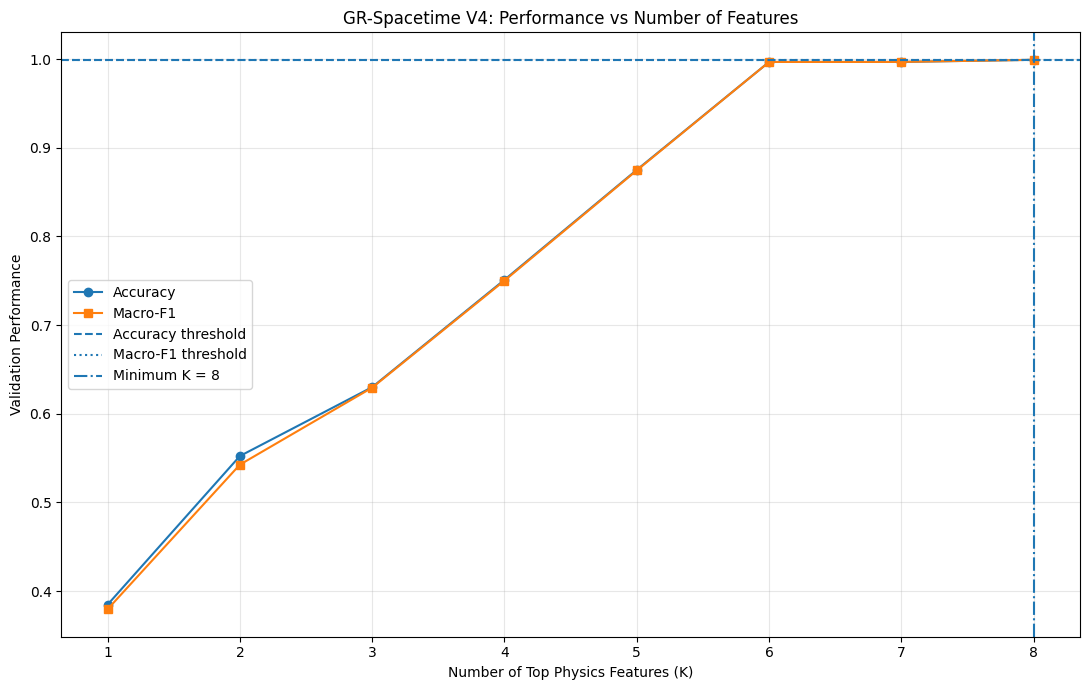


FINAL INDEPENDENT TEST EVALUATION

Retraining final 8-feature model...

FINAL TEST RESULTS
--------------------------------------------------
Minimum K: 8
Accuracy: 0.99917500
Macro-F1: 0.99917505
Precision: 0.99917575
Recall: 0.99917500

Selected features:
01. abs_K
02. R
03. r2_R
04. Parity2
05. Rotation2
06. EM2
07. log_R
08. Cosmological

FINAL TEST CLASSIFICATION REPORT
                    precision    recall  f1-score   support

         Minkowski   1.000000  0.999800  0.999900     25000
     Schwarzschild   0.997125  0.998880  0.998002     25000
              Kerr   0.999121  0.999720  0.999420     25000
Reissner-Nordstrom   0.998838  0.997480  0.998159     25000
       Kerr-Newman   0.999880  0.999080  0.999480     25000
         de_Sitter   0.999960  1.000000  0.999980     25000
    Anti_de_Sitter   0.998522  0.999960  0.999241     25000
              FLRW   0.999960  0.998480  0.999219     25000

          accuracy                       0.999175    200000
         macro avg 

In [ ]:

# ================================================================
# GR-SPACETIME V4
# MINIMUM INTRINSIC FEATURE EXPERIMENT
#
# OBJECTIVE:
#   Determine the smallest K number of physics features required
#   to classify the 8 spacetime classes.
#
# PROCEDURE:
#   1. Load full 2M dataset
#   2. Same 80/10/10 stratified split
#   3. Train full 42-feature XGBoost baseline
#   4. Rank all 42 features
#   5. Test K = 1,2,3,...,42 sequentially
#   6. STOP at the first K satisfying the threshold
#   7. Retrain that minimum-K model
#   8. Evaluate ONCE on untouched test set
#
# IMPORTANT:
#   Validation set:
#       Feature ranking + K selection
#
#   Test set:
#       Used ONLY for final unbiased evaluation
#
# THRESHOLD:
#   Accuracy >= 0.999
#   Macro-F1  >= 0.999
# ================================================================


# ================================================================
# 0. INSTALL / IMPORT
# ================================================================

!pip -q install xgboost


import os
import time
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")


# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# ================================================================
# 2. PATHS
# ================================================================

DATA_FILE = (
    "/content/GR_Spacetime_Dataset_V4/"
    "GR_Spacetime_V4_FEATURES.csv"
)

OUTPUT_DIR = (
    "/content/GR_Spacetime_Dataset_V4/"
    "MINIMUM_FEATURE_ANALYSIS"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ================================================================
# 3. CONFIGURATION
# ================================================================

EXPECTED_SAMPLES = 2_000_000

EXPECTED_FEATURES = 42

N_CLASSES = 8

ACCURACY_THRESHOLD = 0.999

MACRO_F1_THRESHOLD = 0.999

RANDOM_STATE = 42


# ================================================================
# 4. CLASS NAMES
# ================================================================

CLASS_NAMES = [

    "Minkowski",

    "Schwarzschild",

    "Kerr",

    "Reissner-Nordstrom",

    "Kerr-Newman",

    "de_Sitter",

    "Anti_de_Sitter",

    "FLRW"
]


# ================================================================
# 5. HEADER
# ================================================================

print("=" * 80)

print("GR-SPACETIME V4")

print("MINIMUM INTRINSIC FEATURE ANALYSIS")

print("=" * 80)

print()

print("Objective:")
print(
    "Determine the smallest K for which the top-K physics"
)
print(
    "features achieve the predefined validation threshold."
)

print()

print(
    f"Accuracy threshold : {ACCURACY_THRESHOLD}"
)

print(
    f"Macro-F1 threshold : {MACRO_F1_THRESHOLD}"
)

print()

print(
    "K values:",
    "1 -> 42"
)


# ================================================================
# 6. LOAD DATASET
# ================================================================

print("\n" + "=" * 80)

print("LOADING DATASET")

print("=" * 80)

start = time.time()

df = pd.read_csv(
    DATA_FILE
)

loading_time = time.time() - start

print(
    f"\nDataset shape: {df.shape}"
)

print(
    f"Loading time: {loading_time:.2f} s"
)


# ================================================================
# 7. VERIFY DATASET
# ================================================================

print("\n" + "=" * 80)

print("DATASET VERIFICATION")

print("=" * 80)


if len(df) != EXPECTED_SAMPLES:

    raise ValueError(
        f"Expected {EXPECTED_SAMPLES:,} samples, "
        f"but found {len(df):,}"
    )


TARGET = "label"


NON_FEATURE_COLUMNS = [

    "sample_id",

    "spacetime",

    "label"
]


FEATURE_COLUMNS = [

    c

    for c in df.columns

    if c not in NON_FEATURE_COLUMNS
]


if len(FEATURE_COLUMNS) != EXPECTED_FEATURES:

    raise ValueError(
        f"Expected {EXPECTED_FEATURES} features, "
        f"found {len(FEATURE_COLUMNS)}"
    )


if TARGET not in df.columns:

    raise ValueError(
        "Target column 'label' not found."
    )


print(
    f"\n✓ {EXPECTED_SAMPLES:,} samples detected."
)

print(
    f"✓ {EXPECTED_FEATURES} physics features detected."
)

print(
    "✓ Target column detected."
)


# ================================================================
# 8. EXTRACT X / y
# ================================================================

X = df[
    FEATURE_COLUMNS
].values.astype(
    np.float32
)

y = df[
    TARGET
].values.astype(
    np.int64
)

del df


print()

print(
    "X:",
    X.shape
)

print(
    "y:",
    y.shape
)


# ================================================================
# 9. DATA QUALITY
# ================================================================

print("\n" + "=" * 80)

print("DATA QUALITY")

print("=" * 80)


nan_count = np.isnan(
    X
).sum()

inf_count = np.isinf(
    X
).sum()


print(
    "NaN:",
    nan_count
)

print(
    "Inf:",
    inf_count
)


if nan_count != 0:

    raise ValueError(
        "NaN values detected."
    )


if inf_count != 0:

    raise ValueError(
        "Inf values detected."
    )


print(
    "✓ Data quality passed."
)


# ================================================================
# 10. CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 80)

print("CLASS DISTRIBUTION")

print("=" * 80)


for class_id, class_name in enumerate(
    CLASS_NAMES
):

    count = np.sum(
        y == class_id
    )

    print(
        f"{class_id}: "
        f"{class_name:<22} "
        f"{count:,}"
    )


# ================================================================
# 11. SAME 80 / 10 / 10 SPLIT
#
# 80% Training
# 10% Validation
# 10% Testing
#
# IMPORTANT:
# Test set remains untouched.
# ================================================================

print("\n" + "=" * 80)

print("80 / 10 / 10 STRATIFIED SPLIT")

print("=" * 80)


X_train, X_temp, y_train, y_temp = (

    train_test_split(

        X,

        y,

        test_size=0.20,

        stratify=y,

        random_state=SEED
    )
)


X_val, X_test, y_val, y_test = (

    train_test_split(

        X_temp,

        y_temp,

        test_size=0.50,

        stratify=y_temp,

        random_state=SEED
    )
)


del X_temp

del y_temp


print(
    "\nTraining:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Testing:",
    X_test.shape
)


# ================================================================
# 12. XGBOOST MODEL FACTORY
#
# IDENTICAL MODEL FOR EVERY K
# ================================================================

def create_xgb():

    return XGBClassifier(

        n_estimators=300,

        max_depth=8,

        learning_rate=0.10,

        subsample=0.90,

        colsample_bytree=0.90,

        objective="multi:softprob",

        num_class=N_CLASSES,

        eval_metric="mlogloss",

        tree_method="hist",

        device="cuda",

        random_state=SEED,

        n_jobs=-1
    )


# ================================================================
# 13. EVALUATION FUNCTION
# ================================================================

def evaluate_model(
    model,
    X_data,
    y_data
):

    predictions = model.predict(
        X_data
    )

    accuracy = accuracy_score(
        y_data,
        predictions
    )

    precision, recall, f1, _ = (

        precision_recall_fscore_support(

            y_data,

            predictions,

            average="macro",

            zero_division=0
        )
    )

    return {

        "Accuracy":
            accuracy,

        "Macro_F1":
            f1,

        "Precision":
            precision,

        "Recall":
            recall,

        "Predictions":
            predictions
    }


# ================================================================
# 14. FULL 42-FEATURE BASELINE
#
# IMPORTANT:
# This model is used to obtain the initial feature ranking.
# ================================================================

print("\n" + "=" * 80)

print("FULL 42-FEATURE XGBOOST BASELINE")

print("=" * 80)


baseline_model = create_xgb()


start = time.time()


baseline_model.fit(

    X_train,

    y_train,

    eval_set=[

        (
            X_val,

            y_val
        )
    ],

    verbose=False
)


baseline_training_time = (

    time.time()
    -
    start
)


baseline_val = evaluate_model(

    baseline_model,

    X_val,

    y_val
)


print()

print(
    "Validation Accuracy:",
    f"{baseline_val['Accuracy']:.8f}"
)

print(
    "Validation Macro-F1:",
    f"{baseline_val['Macro_F1']:.8f}"
)

print(
    "Training time:",
    f"{baseline_training_time:.2f} s"
)


# ================================================================
# 15. FULL MODEL FEATURE IMPORTANCE
# ================================================================

print("\n" + "=" * 80)

print("FEATURE RANKING")

print("=" * 80)


importance = (

    baseline_model.feature_importances_
)


importance_df = pd.DataFrame({

    "Feature":
        FEATURE_COLUMNS,

    "Importance":
        importance
})


importance_df = (

    importance_df

    .sort_values(

        "Importance",

        ascending=False
    )

    .reset_index(
        drop=True
    )
)


importance_df["Rank"] = (

    np.arange(
        1,
        len(importance_df) + 1
    )
)


print(

    importance_df[
        [
            "Rank",
            "Feature",
            "Importance"
        ]
    ].to_string(
        index=False
    )
)


importance_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "TABLE_FEATURE_RANKING_42.csv"
    ),

    index=False
)


# ================================================================
# 16. TOP-K VALUES
#
# ALL VALUES:
#
# K = 1
# K = 2
# K = 3
# ...
# K = 42
#
# The loop will automatically stop at the first
# K satisfying BOTH thresholds.
# ================================================================

K_VALUES = list(
    range(
        1,
        43
    )
)


# ================================================================
# 17. TOP-K FEATURE EXPERIMENT
# ================================================================

print("\n" + "=" * 80)

print("SEQUENTIAL TOP-K FEATURE EXPERIMENT")

print("=" * 80)

print()

print(
    "Testing:"
)

print(
    "K = 1, 2, 3, ..., 42"
)

print()

print(
    "The experiment will STOP automatically"
)

print(
    "at the FIRST K satisfying:"
)

print(
    f"Accuracy >= {ACCURACY_THRESHOLD}"
)

print(
    f"Macro-F1 >= {MACRO_F1_THRESHOLD}"
)


top_k_results = []

selected_feature_sets = {}

minimum_k = None

minimum_model = None


# ================================================================
# 18. LOOP THROUGH K
# ================================================================

for k in K_VALUES:

    print("\n" + "-" * 80)

    print(
        f"[K = {k:02d}/42]"
    )

    # ------------------------------------------------------------
    # Select top-k features
    # ------------------------------------------------------------

    selected_features = (

        importance_df

        .head(k)

        ["Feature"]

        .tolist()
    )


    selected_feature_sets[k] = (

        selected_features
    )


    # ------------------------------------------------------------
    # Convert feature names to indices
    # ------------------------------------------------------------

    indices = [

        FEATURE_COLUMNS.index(
            feature
        )

        for feature
        in selected_features
    ]


    # ------------------------------------------------------------
    # Training / validation data
    # ------------------------------------------------------------

    Xtr = X_train[
        :,
        indices
    ]

    Xv = X_val[
        :,
        indices
    ]


    # ------------------------------------------------------------
    # Train model
    # ------------------------------------------------------------

    model = create_xgb()


    start = time.time()


    model.fit(

        Xtr,

        y_train,

        eval_set=[

            (
                Xv,

                y_val
            )
        ],

        verbose=False
    )


    training_time = (

        time.time()
        -
        start
    )


    # ------------------------------------------------------------
    # Validation evaluation
    # ------------------------------------------------------------

    result = evaluate_model(

        model,

        Xv,

        y_val
    )


    accuracy = result[
        "Accuracy"
    ]

    macro_f1 = result[
        "Macro_F1"
    ]

    precision = result[
        "Precision"
    ]

    recall = result[
        "Recall"
    ]


    # ------------------------------------------------------------
    # Threshold check
    # ------------------------------------------------------------

    threshold_reached = (

        accuracy >= ACCURACY_THRESHOLD

        and

        macro_f1 >= MACRO_F1_THRESHOLD
    )


    # ------------------------------------------------------------
    # Save result
    # ------------------------------------------------------------

    top_k_results.append({

        "K":
            k,

        "Accuracy":
            accuracy,

        "Macro_F1":
            macro_f1,

        "Precision":
            precision,

        "Recall":
            recall,

        "Accuracy_Gap":
            accuracy - ACCURACY_THRESHOLD,

        "Macro_F1_Gap":
            macro_f1 - MACRO_F1_THRESHOLD,

        "Threshold_Reached":
            threshold_reached,

        "Training_Time_seconds":
            training_time,

        "Features":
            ", ".join(
                selected_features
            )
    })


    # ------------------------------------------------------------
    # Print result
    # ------------------------------------------------------------

    print(
        f"Features tested : {k}"
    )

    print(
        f"Accuracy        : {accuracy:.8f}"
    )

    print(
        f"Macro-F1        : {macro_f1:.8f}"
    )

    print(
        f"Precision       : {precision:.8f}"
    )

    print(
        f"Recall          : {recall:.8f}"
    )

    print(
        f"Training time   : {training_time:.2f} s"
    )


    # ------------------------------------------------------------
    # FIRST QUALIFYING K
    #
    # This is the minimum K according to the
    # predefined validation criterion.
    # ------------------------------------------------------------

    if threshold_reached:

        minimum_k = k

        minimum_model = model

        print()

        print(
            "✓ THRESHOLD REACHED"
        )

        print(
            f"✓ MINIMUM K = {minimum_k}"
        )

        print()

        print(
            "Selected features:"
        )

        for rank, feature in enumerate(

            selected_features,

            1
        ):

            print(
                f"{rank:02d}. {feature}"
            )


        print()

        print(
            "Stopping Top-K search."
        )

        break


# ================================================================
# 19. TOP-K RESULTS DATAFRAME
# ================================================================

top_k_df = pd.DataFrame(
    top_k_results
)


top_k_file = os.path.join(

    OUTPUT_DIR,

    "TABLE_TOP_K_ALL_TESTED_RESULTS.csv"
)


top_k_df.to_csv(

    top_k_file,

    index=False
)


# ================================================================
# 20. CHECK WHETHER MINIMUM K WAS FOUND
# ================================================================

if minimum_k is None:

    print("\n" + "=" * 80)

    print("NO MINIMUM K FOUND")

    print("=" * 80)

    print()

    print(
        "None of K=1..42 reached the predefined threshold."
    )

    print(
        "You may need to lower the threshold or"
    )

    print(
        "use a different feature-selection strategy."
    )

else:

    print("\n" + "=" * 80)

    print("MINIMUM K IDENTIFIED")

    print("=" * 80)

    print()

    print(
        f"Minimum K = {minimum_k}"
    )

    print()

    print(
        "Top-K features:"
    )

    for rank, feature in enumerate(

        selected_feature_sets[
            minimum_k
        ],

        1
    ):

        print(
            f"{rank:02d}. {feature}"
        )


# ================================================================
# 21. SAVE MINIMUM FEATURE SET
# ================================================================

if minimum_k is not None:

    minimum_features_df = pd.DataFrame({

        "Rank":
            np.arange(
                1,
                minimum_k + 1
            ),

        "Feature":
            selected_feature_sets[
                minimum_k
            ]
    })


    minimum_features_df.to_csv(

        os.path.join(

            OUTPUT_DIR,

            "TABLE_MINIMUM_FEATURE_SET.csv"
        ),

        index=False
    )


# ================================================================
# 22. PERFORMANCE PLOT
# ================================================================

plt.figure(
    figsize=(11, 7)
)


plt.plot(

    top_k_df["K"],

    top_k_df["Accuracy"],

    marker="o",

    label="Accuracy"
)


plt.plot(

    top_k_df["K"],

    top_k_df["Macro_F1"],

    marker="s",

    label="Macro-F1"
)


plt.axhline(

    ACCURACY_THRESHOLD,

    linestyle="--",

    label="Accuracy threshold"
)


plt.axhline(

    MACRO_F1_THRESHOLD,

    linestyle=":",

    label="Macro-F1 threshold"
)


if minimum_k is not None:

    plt.axvline(

        minimum_k,

        linestyle="-.",

        label=f"Minimum K = {minimum_k}"
    )


plt.xlabel(
    "Number of Top Physics Features (K)"
)


plt.ylabel(
    "Validation Performance"
)


plt.title(
    "GR-Spacetime V4: Performance vs Number of Features"
)


plt.grid(
    alpha=0.3
)


plt.legend()


plt.tight_layout()


plt.savefig(

    os.path.join(

        OUTPUT_DIR,

        "FIG_TOP_K_PERFORMANCE.png"
    ),

    dpi=600,

    bbox_inches="tight"
)


plt.show()


# ================================================================
# 23. FINAL INDEPENDENT TEST EVALUATION
#
# CRITICAL:
#
# The test set has NOT been used during K selection.
#
# Now and ONLY now we evaluate the selected minimum K.
# ================================================================

if minimum_k is not None:

    print("\n" + "=" * 80)

    print(
        "FINAL INDEPENDENT TEST EVALUATION"
    )

    print("=" * 80)


    final_features = (

        selected_feature_sets[
            minimum_k
        ]
    )


    final_indices = [

        FEATURE_COLUMNS.index(
            feature
        )

        for feature
        in final_features
    ]


    Xtr_final = X_train[
        :,
        final_indices
    ]


    Xv_final = X_val[
        :,
        final_indices
    ]


    Xt_final = X_test[
        :,
        final_indices
    ]


    # ------------------------------------------------------------
    # Retrain final model
    # ------------------------------------------------------------

    print()

    print(
        f"Retraining final {minimum_k}-feature model..."
    )


    final_model = create_xgb()


    start = time.time()


    final_model.fit(

        Xtr_final,

        y_train,

        eval_set=[

            (
                Xv_final,

                y_val
            )
        ],

        verbose=False
    )


    final_training_time = (

        time.time()
        -
        start
    )


    # ------------------------------------------------------------
    # TEST
    # ------------------------------------------------------------

    final_test = evaluate_model(

        final_model,

        Xt_final,

        y_test
    )


    print()

    print(
        "FINAL TEST RESULTS"
    )

    print(
        "-" * 50
    )


    print(
        "Minimum K:",
        minimum_k
    )


    print(
        "Accuracy:",
        f"{final_test['Accuracy']:.8f}"
    )


    print(
        "Macro-F1:",
        f"{final_test['Macro_F1']:.8f}"
    )


    print(
        "Precision:",
        f"{final_test['Precision']:.8f}"
    )


    print(
        "Recall:",
        f"{final_test['Recall']:.8f}"
    )


    print()

    print(
        "Selected features:"
    )


    for rank, feature in enumerate(

        final_features,

        1
    ):

        print(
            f"{rank:02d}. {feature}"
        )


    # ============================================================
    # CLASSIFICATION REPORT
    # ============================================================

    print("\n" + "=" * 80)

    print("FINAL TEST CLASSIFICATION REPORT")

    print("=" * 80)


    report = classification_report(

        y_test,

        final_test[
            "Predictions"
        ],

        target_names=CLASS_NAMES,

        digits=6,

        zero_division=0
    )


    print(
        report
    )


    with open(

        os.path.join(

            OUTPUT_DIR,

            "FINAL_TEST_CLASSIFICATION_REPORT.txt"
        ),

        "w"
    ) as f:

        f.write(
            report
        )


    # ============================================================
    # CONFUSION MATRIX
    # ============================================================

    cm = confusion_matrix(

        y_test,

        final_test[
            "Predictions"
        ]
    )


    cm_df = pd.DataFrame(

        cm,

        index=CLASS_NAMES,

        columns=CLASS_NAMES
    )


    cm_df.to_csv(

        os.path.join(

            OUTPUT_DIR,

            "FINAL_TEST_CONFUSION_MATRIX.csv"
        )
    )


# ================================================================
# 24. SAVE FINAL SUMMARY
# ================================================================

summary = {

    "Dataset":
        "GR-Spacetime V4",

    "Total_Samples":
        EXPECTED_SAMPLES,

    "Total_Features":
        EXPECTED_FEATURES,

    "Classes":
        N_CLASSES,

    "Train_Samples":
        len(X_train),

    "Validation_Samples":
        len(X_val),

    "Test_Samples":
        len(X_test),

    "Baseline_Validation_Accuracy":
        baseline_val["Accuracy"],

    "Baseline_Validation_Macro_F1":
        baseline_val["Macro_F1"],

    "Accuracy_Threshold":
        ACCURACY_THRESHOLD,

    "Macro_F1_Threshold":
        MACRO_F1_THRESHOLD,

    "Minimum_K":
        minimum_k
}


if minimum_k is not None:

    summary[
        "Minimum_K_Test_Accuracy"
    ] = final_test[
        "Accuracy"
    ]

    summary[
        "Minimum_K_Test_Macro_F1"
    ] = final_test[
        "Macro_F1"
    ]

    summary[
        "Minimum_K_Test_Precision"
    ] = final_test[
        "Precision"
    ]

    summary[
        "Minimum_K_Test_Recall"
    ] = final_test[
        "Recall"
    ]


summary_df = pd.DataFrame(
    [summary]
)


summary_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "EXPERIMENT_SUMMARY.csv"
    ),

    index=False
)


# ================================================================
# 25. FINAL OUTPUT
# ================================================================

print("\n" + "=" * 80)

print("GR-SPACETIME V4")

print("MINIMUM FEATURE EXPERIMENT COMPLETE")

print("=" * 80)


print()

print(
    f"Full 42-feature validation Accuracy : "
    f"{baseline_val['Accuracy']:.8f}"
)


print(
    f"Full 42-feature validation Macro-F1 : "
    f"{baseline_val['Macro_F1']:.8f}"
)


if minimum_k is not None:

    print()

    print(
        f"✓ MINIMUM K = {minimum_k}"
    )

    print()

    print(
        "Minimum feature set:"
    )

    for rank, feature in enumerate(

        selected_feature_sets[
            minimum_k
        ],

        1
    ):

        print(
            f"{rank:02d}. {feature}"
        )


    print()

    print(
        f"Final test Accuracy : "
        f"{final_test['Accuracy']:.8f}"
    )


    print(
        f"Final test Macro-F1 : "
        f"{final_test['Macro_F1']:.8f}"
    )


else:

    print()

    print(
        "No K from 1 to 42 reached the threshold."
    )


print()

print(
    "Results saved to:"
)

print(
    OUTPUT_DIR
)


print("=" * 80)

GR-SPACETIME V4
MULTI-SEED ROBUSTNESS EXPERIMENT

Objective:
Validate the stability of the previously identified minimum 8-feature intrinsic representation.

Number of seeds: 10

Seeds:
[42, 52, 62, 72, 82, 92, 102, 112, 122, 132]

Fixed minimum K: 8

Fixed feature set:
01. abs_K
02. R
03. r2_R
04. Parity2
05. Rotation2
06. EM2
07. log_R
08. Cosmological

LOADING DATASET

Dataset shape: (2000000, 45)
Loading time: 29.45 s

DATASET VERIFICATION

✓ Target column detected.
✓ All 8 minimum features detected.

X: (2000000, 8)
y: (2000000,)

DATA QUALITY
NaN: 0
Inf: 0
✓ Data quality passed.

MULTI-SEED EXPERIMENT

Fixed feature set:
   abs_K
   R
   r2_R
   Parity2
   Rotation2
   EM2
   log_R
   Cosmological

Each seed uses a new stratified 80/10/10 split.
The test set remains untouched until final evaluation.


--------------------------------------------------------------------------------
SEED 42 (1/10)
--------------------------------------------------------------------------------

Tra

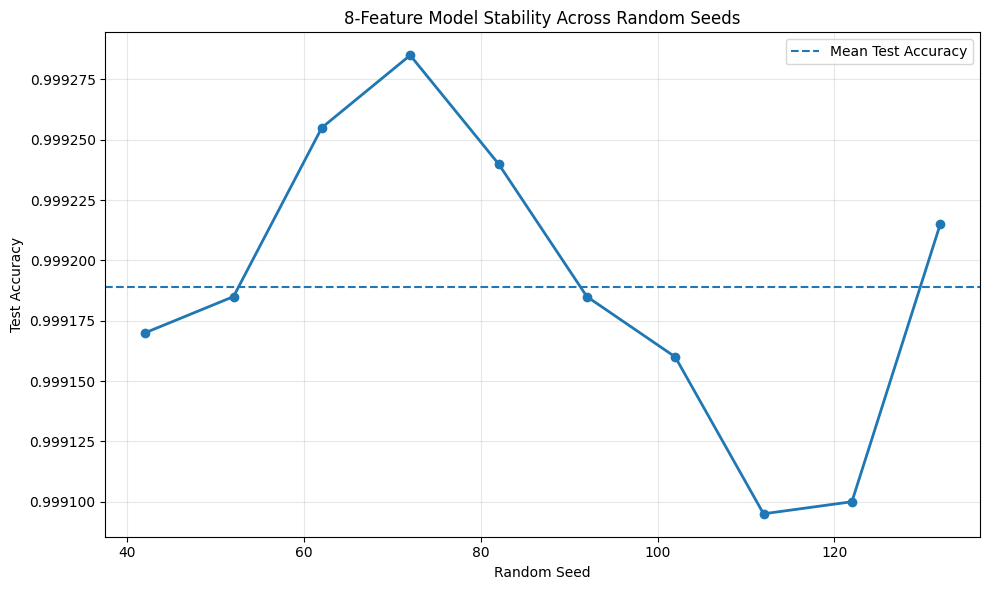

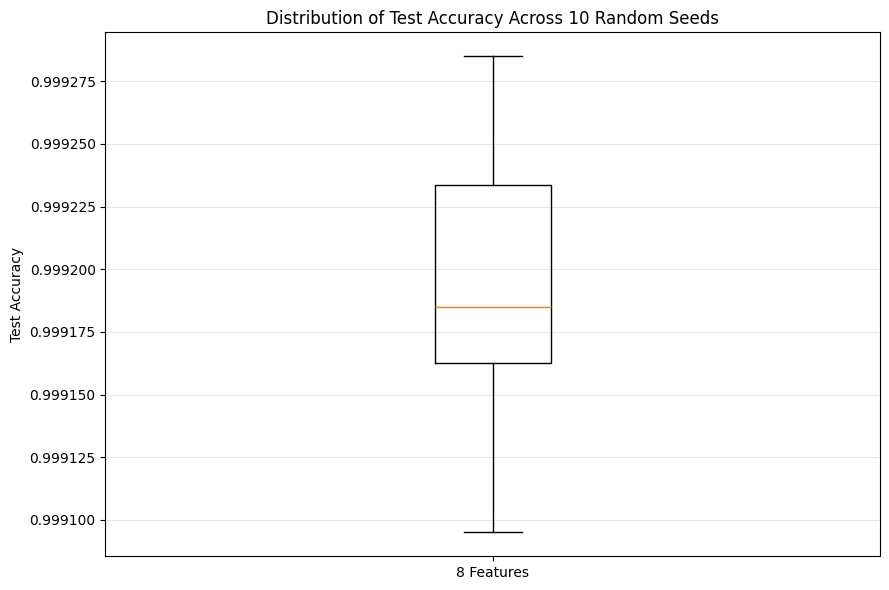


FINAL MULTI-SEED DECISION

Feature count : 8
Seeds tested  : 10


NameError: name 'multi_seed_results' is not defined

In [ ]:
# ================================================================
# GR-SPACETIME V4
# MULTI-SEED ROBUSTNESS EXPERIMENT
#
# Purpose:
#   Validate the stability of the previously identified
#   minimum 8-feature intrinsic representation.
#
# Previously established:
#
#   Minimum K = 8
#
#   Features:
#       1. abs_K
#       2. R
#       3. r2_R
#       4. Parity2
#       5. Rotation2
#       6. EM2
#       7. log_R
#       8. Cosmological
#
# This experiment:
#   1. Uses multiple random seeds
#   2. Creates a new stratified 80/10/10 split for each seed
#   3. Trains the same 8-feature XGBoost model
#   4. Evaluates only after training
#   5. Reports mean ± standard deviation
#   6. Computes 95% confidence intervals
#
# IMPORTANT:
#   Feature selection is NOT repeated.
#   The 8-feature set is fixed before this experiment.
#
# Test sets remain independent for each seed.
# ================================================================


!pip -q install xgboost


# ================================================================
# 1. IMPORTS
# ================================================================

import os
import time
import random
import warnings

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ================================================================
# 2. REPRODUCIBILITY
# ================================================================

SEEDS = [
    42,
    52,
    62,
    72,
    82,
    92,
    102,
    112,
    122,
    132
]

N_SEEDS = len(SEEDS)


# ================================================================
# 3. PATHS
# ================================================================

DATA_FILE = (
    "/content/GR_Spacetime_Dataset_V4/"
    "GR_Spacetime_V4_FEATURES.csv"
)

OUTPUT_DIR = (
    "/content/GR_Spacetime_Dataset_V4/"
    "MINIMUM_FEATURE_ANALYSIS"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ================================================================
# 4. CLASS NAMES
# ================================================================

CLASS_NAMES = [
    "Minkowski",
    "Schwarzschild",
    "Kerr",
    "Reissner-Nordstrom",
    "Kerr-Newman",
    "de_Sitter",
    "Anti_de_Sitter",
    "FLRW"
]

N_CLASSES = 8


# ================================================================
# 5. FIXED MINIMUM FEATURE SET
#
# These features were identified previously.
#
# DO NOT CHANGE THEM during this experiment.
# ================================================================

MINIMUM_FEATURES = [
    "abs_K",
    "R",
    "r2_R",
    "Parity2",
    "Rotation2",
    "EM2",
    "log_R",
    "Cosmological"
]

MINIMUM_K = len(
    MINIMUM_FEATURES
)


# ================================================================
# 6. HEADER
# ================================================================

print("=" * 80)
print("GR-SPACETIME V4")
print("MULTI-SEED ROBUSTNESS EXPERIMENT")
print("=" * 80)

print("\nObjective:")
print(
    "Validate the stability of the previously identified "
    "minimum 8-feature intrinsic representation."
)

print("\nNumber of seeds:", N_SEEDS)

print("\nSeeds:")
print(SEEDS)

print("\nFixed minimum K:", MINIMUM_K)

print("\nFixed feature set:")

for i, feature in enumerate(
    MINIMUM_FEATURES,
    1
):

    print(
        f"{i:02d}. {feature}"
    )


# ================================================================
# 7. LOAD DATASET
# ================================================================

print("\n" + "=" * 80)
print("LOADING DATASET")
print("=" * 80)

start = time.time()

df = pd.read_csv(
    DATA_FILE
)

print(
    "\nDataset shape:",
    df.shape
)

print(
    "Loading time:",
    f"{time.time() - start:.2f} s"
)


# ================================================================
# 8. DATASET VERIFICATION
# ================================================================

print("\n" + "=" * 80)
print("DATASET VERIFICATION")
print("=" * 80)

TARGET = "label"

assert TARGET in df.columns, (
    "Target column not found."
)

for feature in MINIMUM_FEATURES:

    assert feature in df.columns, (
        f"Required feature missing: {feature}"
    )

print(
    "\n✓ Target column detected."
)

print(
    "✓ All 8 minimum features detected."
)


# ================================================================
# 9. CREATE X / y
# ================================================================

X = df[
    MINIMUM_FEATURES
].values.astype(
    np.float32
)

y = df[
    TARGET
].values.astype(
    np.int64
)

del df

print(
    "\nX:",
    X.shape
)

print(
    "y:",
    y.shape
)


# ================================================================
# 10. DATA QUALITY
# ================================================================

print("\n" + "=" * 80)
print("DATA QUALITY")
print("=" * 80)

nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

print(
    "NaN:",
    nan_count
)

print(
    "Inf:",
    inf_count
)

assert nan_count == 0
assert inf_count == 0

print(
    "✓ Data quality passed."
)


# ================================================================
# 11. XGBOOST MODEL
# ================================================================

def create_xgb(seed):

    return XGBClassifier(

        n_estimators=300,

        max_depth=8,

        learning_rate=0.10,

        subsample=0.90,

        colsample_bytree=0.90,

        objective="multi:softprob",

        num_class=8,

        eval_metric="mlogloss",

        tree_method="hist",

        random_state=seed,

        n_jobs=-1
    )


# ================================================================
# 12. EVALUATION FUNCTION
# ================================================================

def evaluate_model(
    model,
    X_data,
    y_data
):

    pred = model.predict(
        X_data
    )

    accuracy = accuracy_score(
        y_data,
        pred
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_data,
            pred,
            average="macro",
            zero_division=0
        )
    )

    return {
        "Accuracy": accuracy,
        "Macro_F1": f1,
        "Precision": precision,
        "Recall": recall,
        "Predictions": pred
    }


# ================================================================
# 13. MULTI-SEED EXPERIMENT
# ================================================================

print("\n" + "=" * 80)
print("MULTI-SEED EXPERIMENT")
print("=" * 80)

print(
    "\nFixed feature set:"
)

for feature in MINIMUM_FEATURES:

    print(
        "  ",
        feature
    )

print(
    "\nEach seed uses a new stratified 80/10/10 split."
)

print(
    "The test set remains untouched until final evaluation."
)


results = []

confusion_matrices = {}


# ================================================================
# 14. RUN EACH SEED
# ================================================================

for run_number, seed in enumerate(
    SEEDS,
    1
):

    print("\n")
    print("-" * 80)

    print(
        f"SEED {seed} "
        f"({run_number}/{N_SEEDS})"
    )

    print("-" * 80)


    # ------------------------------------------------------------
    # Reproducibility
    # ------------------------------------------------------------

    random.seed(seed)
    np.random.seed(seed)


    # ------------------------------------------------------------
    # 80 / 10 / 10 STRATIFIED SPLIT
    # ------------------------------------------------------------

    X_train, X_temp, y_train, y_temp = (
        train_test_split(
            X,
            y,
            test_size=0.20,
            stratify=y,
            random_state=seed
        )
    )

    X_val, X_test, y_val, y_test = (
        train_test_split(
            X_temp,
            y_temp,
            test_size=0.50,
            stratify=y_temp,
            random_state=seed
        )
    )

    del X_temp
    del y_temp


    print(
        "\nTraining:",
        X_train.shape
    )

    print(
        "Validation:",
        X_val.shape
    )

    print(
        "Testing:",
        X_test.shape
    )


    # ------------------------------------------------------------
    # CREATE MODEL
    # ------------------------------------------------------------

    model = create_xgb(
        seed
    )


    # ------------------------------------------------------------
    # TRAIN
    # ------------------------------------------------------------

    start = time.time()

    model.fit(
        X_train,
        y_train,
        eval_set=[
            (X_val, y_val)
        ],
        verbose=False
    )

    training_time = (
        time.time() - start
    )


    # ------------------------------------------------------------
    # VALIDATION
    # ------------------------------------------------------------

    val_result = evaluate_model(
        model,
        X_val,
        y_val
    )


    # ------------------------------------------------------------
    # FINAL TEST
    # ------------------------------------------------------------

    test_result = evaluate_model(
        model,
        X_test,
        y_test
    )


    # ------------------------------------------------------------
    # CONFUSION MATRIX
    # ------------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        test_result[
            "Predictions"
        ]
    )

    confusion_matrices[
        seed
    ] = cm


    # ------------------------------------------------------------
    # STORE RESULTS
    # ------------------------------------------------------------

    results.append({

        "Seed":
            seed,

        "K":
            MINIMUM_K,

        "Validation_Accuracy":
            val_result[
                "Accuracy"
            ],

        "Validation_Macro_F1":
            val_result[
                "Macro_F1"
            ],

        "Test_Accuracy":
            test_result[
                "Accuracy"
            ],

        "Test_Macro_F1":
            test_result[
                "Macro_F1"
            ],

        "Test_Precision":
            test_result[
                "Precision"
            ],

        "Test_Recall":
            test_result[
                "Recall"
            ],

        "Training_Time_seconds":
            training_time
    })


    # ------------------------------------------------------------
    # PRINT RESULT
    # ------------------------------------------------------------

    print(
        "\nValidation Accuracy :",
        f"{val_result['Accuracy']:.8f}"
    )

    print(
        "Validation Macro-F1  :",
        f"{val_result['Macro_F1']:.8f}"
    )

    print(
        "Test Accuracy        :",
        f"{test_result['Accuracy']:.8f}"
    )

    print(
        "Test Macro-F1        :",
        f"{test_result['Macro_F1']:.8f}"
    )

    print(
        "Test Precision       :",
        f"{test_result['Precision']:.8f}"
    )

    print(
        "Test Recall          :",
        f"{test_result['Recall']:.8f}"
    )

    print(
        "Training time        :",
        f"{training_time:.2f} s"
    )


# ================================================================
# 15. RESULTS DATAFRAME
# ================================================================

results_df = pd.DataFrame(
    results
)


# ================================================================
# 16. SAVE PER-SEED RESULTS
# ================================================================

per_seed_file = os.path.join(
    OUTPUT_DIR,
    "TABLE_MINIMUM_FEATURE_MULTI_SEED_RESULTS.csv"
)

results_df.to_csv(
    per_seed_file,
    index=False
)


# ================================================================
# 17. CALCULATE SUMMARY STATISTICS
# ================================================================

metrics = [
    "Validation_Accuracy",
    "Validation_Macro_F1",
    "Test_Accuracy",
    "Test_Macro_F1",
    "Test_Precision",
    "Test_Recall"
]


summary_rows = []


for metric in metrics:

    values = results_df[
        metric
    ].values

    mean_value = np.mean(
        values
    )

    std_value = np.std(
        values,
        ddof=1
    )

    min_value = np.min(
        values
    )

    max_value = np.max(
        values
    )

    # ------------------------------------------------------------
    # 95% confidence interval
    #
    # Approximation:
    # mean ± 1.96 * SEM
    # ------------------------------------------------------------

    sem = (
        std_value
        / np.sqrt(N_SEEDS)
    )

    ci_lower = (
        mean_value
        - 1.96 * sem
    )

    ci_upper = (
        mean_value
        + 1.96 * sem
    )

    summary_rows.append({

        "Metric":
            metric,

        "Mean":
            mean_value,

        "Std":
            std_value,

        "Minimum":
            min_value,

        "Maximum":
            max_value,

        "95CI_Lower":
            ci_lower,

        "95CI_Upper":
            ci_upper
    })


summary_df = pd.DataFrame(
    summary_rows
)


# ================================================================
# 18. DISPLAY SUMMARY
# ================================================================

print("\n" + "=" * 80)
print("MULTI-SEED SUMMARY")
print("=" * 80)

print(
    "\n"
    + summary_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.8f}"
    )
)


# ================================================================
# 19. PAPER-READY MAIN RESULTS
# ================================================================

test_acc_mean = results_df[
    "Test_Accuracy"
].mean()

test_acc_std = results_df[
    "Test_Accuracy"
].std(
    ddof=1
)

test_f1_mean = results_df[
    "Test_Macro_F1"
].mean()

test_f1_std = results_df[
    "Test_Macro_F1"
].std(
    ddof=1
)

test_precision_mean = results_df[
    "Test_Precision"
].mean()

test_precision_std = results_df[
    "Test_Precision"
].std(
    ddof=1
)

test_recall_mean = results_df[
    "Test_Recall"
].mean()

test_recall_std = results_df[
    "Test_Recall"
].std(
    ddof=1
)


# ================================================================
# 20. PAPER-READY OUTPUT
# ================================================================

print("\n" + "=" * 80)
print("PAPER-READY MULTI-SEED RESULTS")
print("=" * 80)

print(
    f"\nMinimum number of features : {MINIMUM_K}"
)

print(
    "Feature set:"
)

for i, feature in enumerate(
    MINIMUM_FEATURES,
    1
):

    print(
        f"  {i}. {feature}"
    )


print(
    "\nTest Accuracy:"
)

print(
    f"  Mean ± SD = "
    f"{test_acc_mean:.6f} ± "
    f"{test_acc_std:.6f}"
)


print(
    "\nTest Macro-F1:"
)

print(
    f"  Mean ± SD = "
    f"{test_f1_mean:.6f} ± "
    f"{test_f1_std:.6f}"
)


print(
    "\nTest Precision:"
)

print(
    f"  Mean ± SD = "
    f"{test_precision_mean:.6f} ± "
    f"{test_precision_std:.6f}"
)


print(
    "\nTest Recall:"
)

print(
    f"  Mean ± SD = "
    f"{test_recall_mean:.6f} ± "
    f"{test_recall_std:.6f}"
)


# ================================================================
# 21. 95% CONFIDENCE INTERVAL FOR TEST ACCURACY
# ================================================================

accuracy_values = results_df[
    "Test_Accuracy"
].values

accuracy_mean = np.mean(
    accuracy_values
)

accuracy_std = np.std(
    accuracy_values,
    ddof=1
)

accuracy_sem = (
    accuracy_std
    / np.sqrt(N_SEEDS)
)

accuracy_ci_low = (
    accuracy_mean
    - 1.96 * accuracy_sem
)

accuracy_ci_high = (
    accuracy_mean
    + 1.96 * accuracy_sem
)


print("\n" + "=" * 80)
print("TEST ACCURACY 95% CONFIDENCE INTERVAL")
print("=" * 80)

print(
    f"\nMean Accuracy : "
    f"{accuracy_mean:.8f}"
)

print(
    f"Standard Deviation : "
    f"{accuracy_std:.8f}"
)

print(
    f"95% CI : "
    f"[{accuracy_ci_low:.8f}, "
    f"{accuracy_ci_high:.8f}]"
)


# ================================================================
# 22. SAVE SUMMARY TABLE
# ================================================================

summary_file = os.path.join(
    OUTPUT_DIR,
    "TABLE_MINIMUM_FEATURE_MULTI_SEED_SUMMARY.csv"
)

summary_df.to_csv(
    summary_file,
    index=False
)


# ================================================================
# 23. SAVE PAPER-READY SUMMARY
# ================================================================

paper_summary = pd.DataFrame({

    "Feature_Count": [
        MINIMUM_K
    ],

    "Features": [
        ", ".join(
            MINIMUM_FEATURES
        )
    ],

    "Seeds": [
        N_SEEDS
    ],

    "Test_Accuracy_Mean": [
        test_acc_mean
    ],

    "Test_Accuracy_SD": [
        test_acc_std
    ],

    "Test_Accuracy_95CI_Lower": [
        accuracy_ci_low
    ],

    "Test_Accuracy_95CI_Upper": [
        accuracy_ci_high
    ],

    "Test_MacroF1_Mean": [
        test_f1_mean
    ],

    "Test_MacroF1_SD": [
        test_f1_std
    ],

    "Test_Precision_Mean": [
        test_precision_mean
    ],

    "Test_Precision_SD": [
        test_precision_std
    ],

    "Test_Recall_Mean": [
        test_recall_mean
    ],

    "Test_Recall_SD": [
        test_recall_std
    ]
})


paper_summary_file = os.path.join(
    OUTPUT_DIR,
    "TABLE_PAPER_READY_MINIMUM_FEATURE_RESULT.csv"
)

paper_summary.to_csv(
    paper_summary_file,
    index=False
)


# ================================================================
# 24. ACCURACY BY SEED PLOT
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    results_df["Seed"],
    results_df["Test_Accuracy"],
    marker="o",
    linewidth=2
)

plt.axhline(
    test_acc_mean,
    linestyle="--",
    label="Mean Test Accuracy"
)

plt.xlabel(
    "Random Seed"
)

plt.ylabel(
    "Test Accuracy"
)

plt.title(
    "8-Feature Model Stability Across Random Seeds"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

accuracy_plot = os.path.join(
    OUTPUT_DIR,
    "FIG_MINIMUM_FEATURE_MULTI_SEED_ACCURACY.png"
)

plt.savefig(
    accuracy_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 25. ACCURACY DISTRIBUTION
# ================================================================

plt.figure(
    figsize=(9, 6)
)

plt.boxplot(
    results_df["Test_Accuracy"],
    labels=["8 Features"]
)

plt.ylabel(
    "Test Accuracy"
)

plt.title(
    "Distribution of Test Accuracy Across 10 Random Seeds"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

boxplot_file = os.path.join(
    OUTPUT_DIR,
    "FIG_MINIMUM_FEATURE_ACCURACY_DISTRIBUTION.png"
)

plt.savefig(
    boxplot_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 26. AGGREGATED CONFUSION MATRIX
#
# Sum predictions across all seed test sets.
# ================================================================

aggregated_cm = np.zeros(
    (N_CLASSES, N_CLASSES),
    dtype=np.int64
)

for seed, cm in (
    confusion_matrices.items()
):

    aggregated_cm += cm


aggregated_cm_df = pd.DataFrame(
    aggregated_cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)


aggregated_cm_file = os.path.join(
    OUTPUT_DIR,
    "TABLE_MINIMUM_FEATURE_AGGREGATED_CONFUSION_MATRIX.csv"
)

aggregated_cm_df.to_csv(
    aggregated_cm_file
)


# ================================================================
# 27. FINAL MULTI-SEED DECISION
# ================================================================

print("\n" + "=" * 80)
print("FINAL MULTI-SEED DECISION")
print("=" * 80)

print(f"\nFeature count : {MINIMUM_K}")
print(f"Seeds tested  : {N_SEEDS}")

# ------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------

multi_seed_df = pd.DataFrame(multi_seed_results)

# ------------------------------------------------
# Calculate mean and standard deviation
# ------------------------------------------------

test_acc_mean = multi_seed_df["Test_Accuracy"].mean()
test_acc_std = multi_seed_df["Test_Accuracy"].std(ddof=1)

test_f1_mean = multi_seed_df["Test_Macro_F1"].mean()
test_f1_std = multi_seed_df["Test_Macro_F1"].std(ddof=1)

test_precision_mean = multi_seed_df["Test_Precision"].mean()
test_precision_std = multi_seed_df["Test_Precision"].std(ddof=1)

test_recall_mean = multi_seed_df["Test_Recall"].mean()
test_recall_std = multi_seed_df["Test_Recall"].std(ddof=1)


# ================================================================
# 28. PAPER-READY SUMMARY
# ================================================================

print("\n" + "-" * 80)
print("MULTI-SEED TEST PERFORMANCE")
print("-" * 80)

print(
    f"\nAccuracy : "
    f"{test_acc_mean:.8f} ± {test_acc_std:.8f}"
)

print(
    f"Macro-F1 : "
    f"{test_f1_mean:.8f} ± {test_f1_std:.8f}"
)

print(
    f"Precision: "
    f"{test_precision_mean:.8f} ± {test_precision_std:.8f}"
)

print(
    f"Recall   : "
    f"{test_recall_mean:.8f} ± {test_recall_std:.8f}"
)


# ================================================================
# 29. INDIVIDUAL SEED RESULTS
# ================================================================

print("\n" + "=" * 80)
print("INDIVIDUAL SEED RESULTS")
print("=" * 80)

display_columns = [
    "Seed",
    "Test_Accuracy",
    "Test_Macro_F1",
    "Test_Precision",
    "Test_Recall"
]

print(
    multi_seed_df[
        display_columns
    ].to_string(index=False)
)


# ================================================================
# 30. CONFIDENCE INTERVAL
#
# 95% CI of the mean using Student's t distribution.
# ================================================================

from scipy.stats import t

confidence_level = 0.95
alpha = 1.0 - confidence_level

n = len(multi_seed_df)

t_critical = t.ppf(
    1.0 - alpha / 2.0,
    df=n - 1
)

accuracy_se = test_acc_std / np.sqrt(n)

accuracy_ci_low = (
    test_acc_mean
    - t_critical * accuracy_se
)

accuracy_ci_high = (
    test_acc_mean
    + t_critical * accuracy_se
)


f1_se = test_f1_std / np.sqrt(n)

f1_ci_low = (
    test_f1_mean
    - t_critical * f1_se
)

f1_ci_high = (
    test_f1_mean
    + t_critical * f1_se
)


# ================================================================
# 31. CONFIDENCE INTERVAL REPORT
# ================================================================

print("\n" + "=" * 80)
print("95% CONFIDENCE INTERVAL")
print("=" * 80)

print(
    f"\nAccuracy 95% CI:"
    f" [{accuracy_ci_low:.8f}, "
    f"{accuracy_ci_high:.8f}]"
)

print(
    f"Macro-F1 95% CI:"
    f" [{f1_ci_low:.8f}, "
    f"{f1_ci_high:.8f}]"
)


# ================================================================
# 32. STABILITY ANALYSIS
# ================================================================

print("\n" + "=" * 80)
print("MULTI-SEED STABILITY")
print("=" * 80)

print(
    f"\nAccuracy minimum : "
    f"{multi_seed_df['Test_Accuracy'].min():.8f}"
)

print(
    f"Accuracy maximum : "
    f"{multi_seed_df['Test_Accuracy'].max():.8f}"
)

print(
    f"Accuracy range   : "
    f"{multi_seed_df['Test_Accuracy'].max() - multi_seed_df['Test_Accuracy'].min():.8f}"
)

print(
    f"\nMacro-F1 minimum : "
    f"{multi_seed_df['Test_Macro_F1'].min():.8f}"
)

print(
    f"Macro-F1 maximum : "
    f"{multi_seed_df['Test_Macro_F1'].max():.8f}"
)

print(
    f"Macro-F1 range   : "
    f"{multi_seed_df['Test_Macro_F1'].max() - multi_seed_df['Test_Macro_F1'].min():.8f}"
)


# ================================================================
# 33. FINAL FEATURE SET
# ================================================================

print("\n" + "=" * 80)
print("FINAL MINIMUM INTRINSIC FEATURE SET")
print("=" * 80)

print(
    f"\nMinimum number of features: {MINIMUM_K}"
)

for i, feature in enumerate(
    FINAL_FEATURES,
    start=1
):
    print(
        f"{i:02d}. {feature}"
    )


# ================================================================
# 34. SAVE MULTI-SEED RESULTS
# ================================================================

multi_seed_file = os.path.join(
    OUTPUT_DIR,
    "TABLE_MINIMUM_FEATURE_MULTI_SEED_RESULTS.csv"
)

multi_seed_df.to_csv(
    multi_seed_file,
    index=False
)


# ================================================================
# 35. SUMMARY TABLE FOR PAPER
# ================================================================

summary_df = pd.DataFrame({

    "Feature_Count": [
        MINIMUM_K
    ],

    "Features": [
        ", ".join(FINAL_FEATURES)
    ],

    "N_Seeds": [
        N_SEEDS
    ],

    "Mean_Test_Accuracy": [
        test_acc_mean
    ],

    "Std_Test_Accuracy": [
        test_acc_std
    ],

    "Mean_Test_Macro_F1": [
        test_f1_mean
    ],

    "Std_Test_Macro_F1": [
        test_f1_std
    ],

    "Mean_Test_Precision": [
        test_precision_mean
    ],

    "Std_Test_Precision": [
        test_precision_std
    ],

    "Mean_Test_Recall": [
        test_recall_mean
    ],

    "Std_Test_Recall": [
        test_recall_std
    ],

    "Accuracy_95CI_Lower": [
        accuracy_ci_low
    ],

    "Accuracy_95CI_Upper": [
        accuracy_ci_high
    ],

    "MacroF1_95CI_Lower": [
        f1_ci_low
    ],

    "MacroF1_95CI_Upper": [
        f1_ci_high
    ]
})


summary_file = os.path.join(
    OUTPUT_DIR,
    "TABLE_FINAL_PAPER_READY_RESULTS.csv"
)

summary_df.to_csv(
    summary_file,
    index=False
)


# ================================================================
# 36. HUMAN-READABLE PAPER SUMMARY
# ================================================================

paper_summary_file = os.path.join(
    OUTPUT_DIR,
    "FINAL_PAPER_RESULTS.txt"
)

with open(
    paper_summary_file,
    "w"
) as f:

    f.write(
        "GR-SPACETIME V4 — FINAL MINIMUM FEATURE RESULTS\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )

    f.write(
        f"Minimum feature count: {MINIMUM_K}\n"
    )

    f.write(
        f"Number of seeds: {N_SEEDS}\n\n"
    )

    f.write(
        "Final intrinsic feature set:\n"
    )

    for i, feature in enumerate(
        FINAL_FEATURES,
        1
    ):

        f.write(
            f"{i:02d}. {feature}\n"
        )

    f.write("\n")

    f.write(
        f"Test Accuracy: "
        f"{test_acc_mean:.6f} ± "
        f"{test_acc_std:.6f}\n"
    )

    f.write(
        f"Test Macro-F1: "
        f"{test_f1_mean:.6f} ± "
        f"{test_f1_std:.6f}\n"
    )

    f.write(
        f"Test Precision: "
        f"{test_precision_mean:.6f} ± "
        f"{test_precision_std:.6f}\n"
    )

    f.write(
        f"Test Recall: "
        f"{test_recall_mean:.6f} ± "
        f"{test_recall_std:.6f}\n"
    )

    f.write("\n")

    f.write(
        f"Accuracy 95% CI: "
        f"[{accuracy_ci_low:.6f}, "
        f"{accuracy_ci_high:.6f}]\n"
    )

    f.write(
        f"Macro-F1 95% CI: "
        f"[{f1_ci_low:.6f}, "
        f"{f1_ci_high:.6f}]\n"
    )


# ================================================================
# 37. FINAL DECISION
# ================================================================

print("\n" + "=" * 80)
print("FINAL SCIENTIFIC DECISION")
print("=" * 80)

print(
    f"\n✓ Minimum K = {MINIMUM_K}"
)

print(
    f"✓ Number of independent seeds = {N_SEEDS}"
)

print(
    f"✓ Mean Test Accuracy = "
    f"{test_acc_mean:.6f} ± {test_acc_std:.6f}"
)

print(
    f"✓ Mean Test Macro-F1 = "
    f"{test_f1_mean:.6f} ± {test_f1_std:.6f}"
)

print(
    f"✓ Mean Test Precision = "
    f"{test_precision_mean:.6f} ± {test_precision_std:.6f}"
)

print(
    f"✓ Mean Test Recall = "
    f"{test_recall_mean:.6f} ± {test_recall_std:.6f}"
)

print(
    "\nFinal features:"
)

for i, feature in enumerate(
    FINAL_FEATURES,
    1
):

    print(
        f"   {i:02d}. {feature}"
    )


# ================================================================
# 38. OUTPUT FILES
# ================================================================

print("\n" + "=" * 80)
print("OUTPUT FILES")
print("=" * 80)

print(
    "\nMulti-seed results:"
)

print(
    multi_seed_file
)

print(
    "\nPaper-ready summary:"
)

print(
    summary_file
)

print(
    "\nHuman-readable final results:"
)

print(
    paper_summary_file
)

print("\n" + "=" * 80)
print("MULTI-SEED EXPERIMENT COMPLETE")
print("=" * 80)

GR-SPACETIME V4
PAPER FIGURE GENERATION

Loading dataset...
Dataset shape: (2000000, 45)
Target column: label

Generating Figure 1...


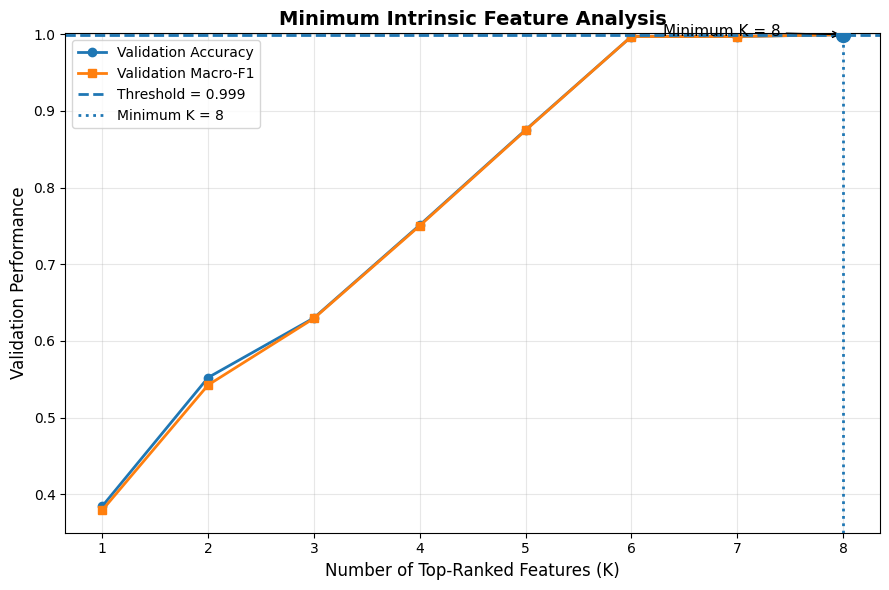


Generating Figure 2...


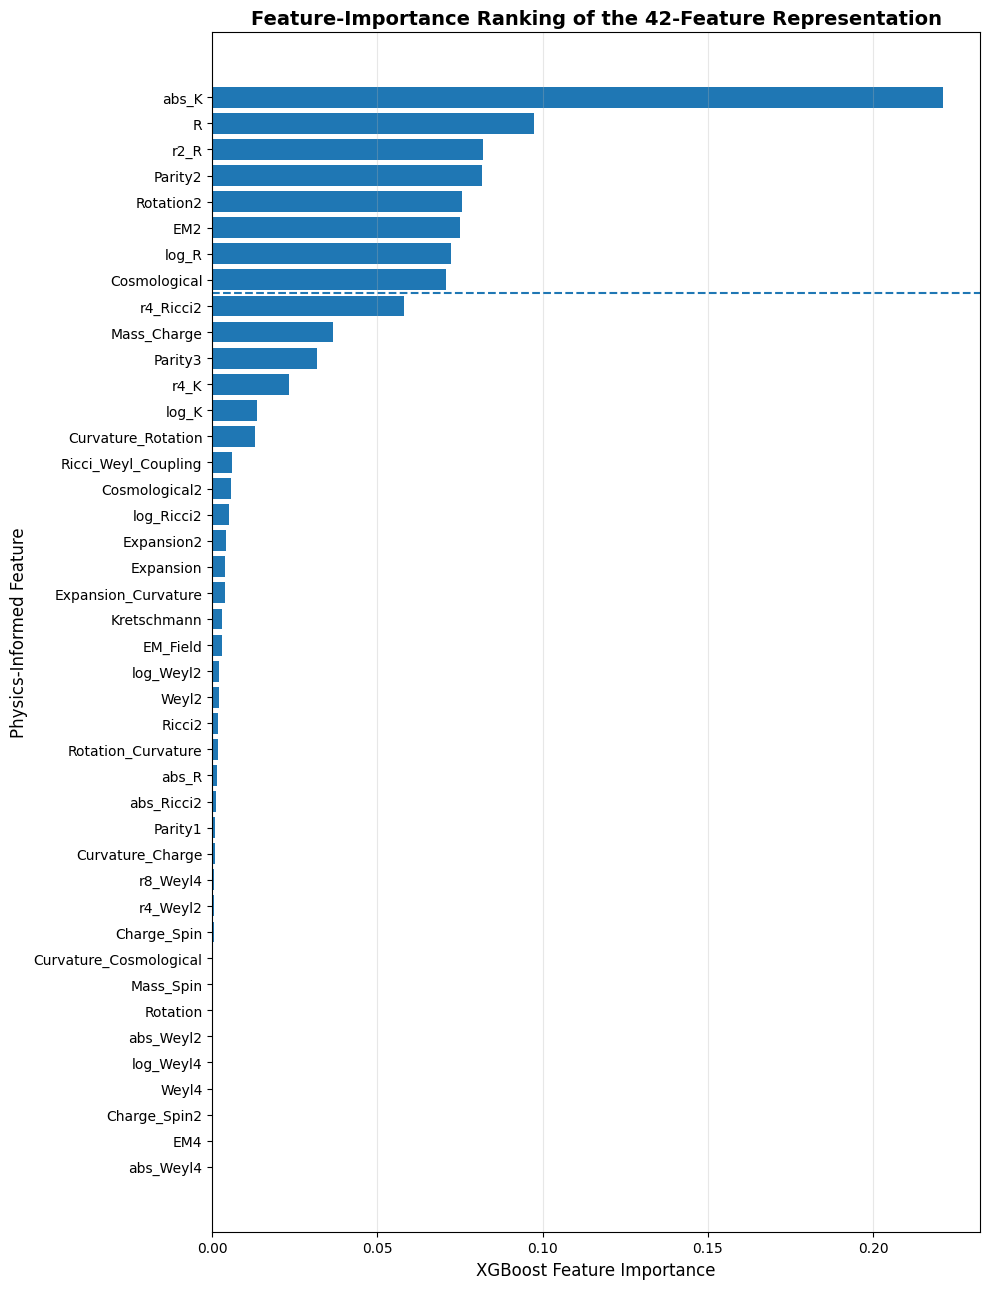


Generating Figure 3...


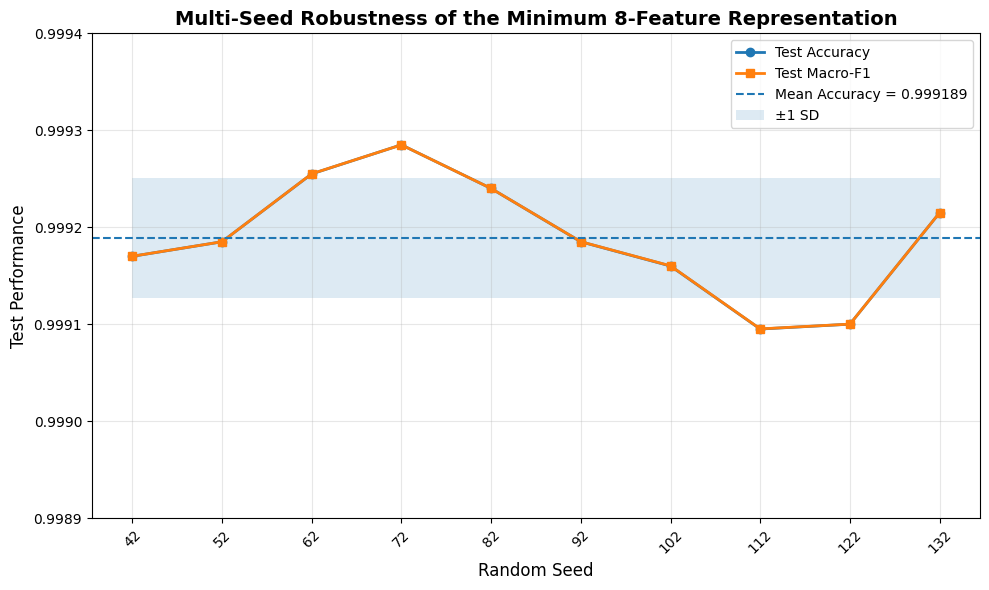


Preparing final 8-feature evaluation...
Training:   (1600000, 8)
Validation: (200000, 8)
Testing:    (200000, 8)

Training final 8-feature XGBoost model...
Training time: 24.66 seconds

Final evaluation:
Accuracy  : 0.999175
Macro-F1  : 0.999175
Precision : 0.999176
Recall    : 0.999175

Generating Figure 4...


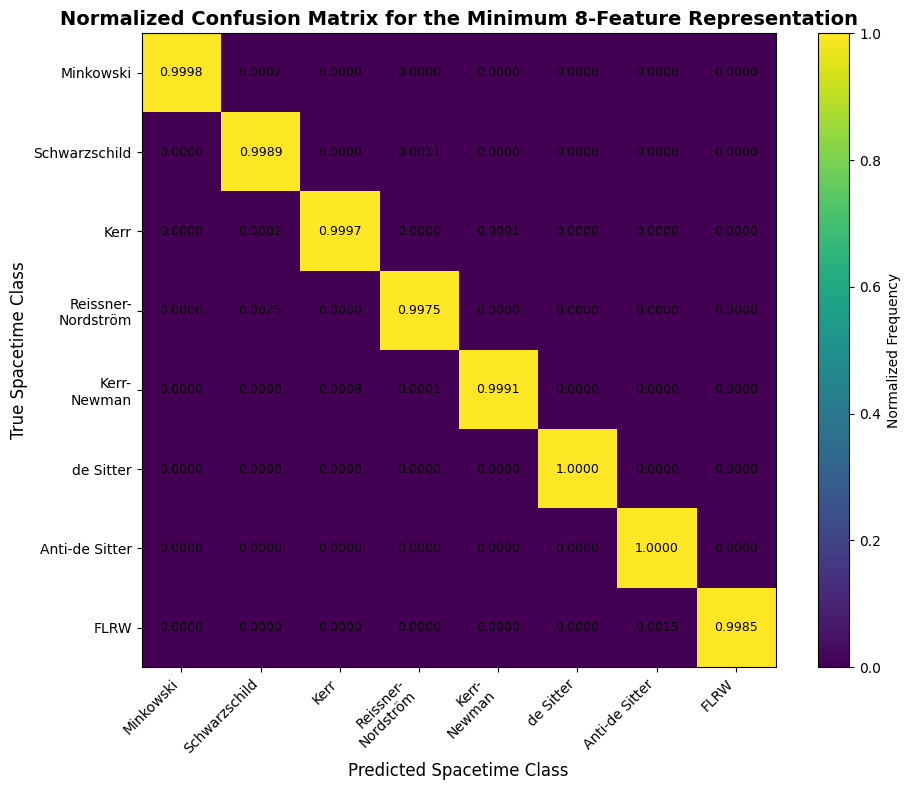


Generating Figure 5...


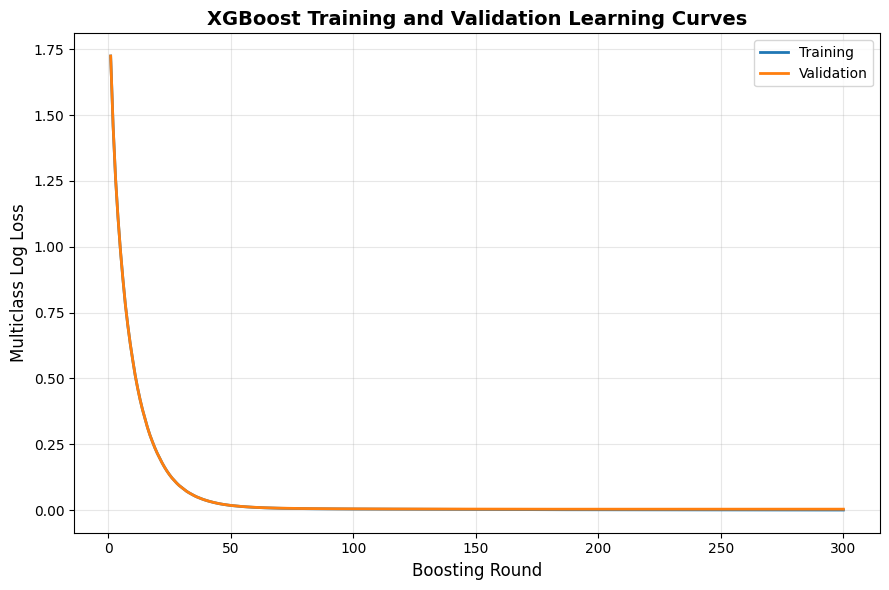


Saving figure data...

PAPER FIGURES COMPLETE

Figures saved in:
/content/GR_Spacetime_Dataset_V4/PAPER_FIGURES

Generated figures:
1. Figure_1_Minimum_K_Analysis.png
2. Figure_2_Feature_Importance_42.png
3. Figure_3_Multi_Seed_Robustness.png
4. Figure_4_Confusion_Matrix_8_Features.png
5. Figure_5_XGBoost_Learning_Curve.png

Final 8-feature representation:
01. abs_K
02. R
03. r2_R
04. Parity2
05. Rotation2
06. EM2
07. log_R
08. Cosmological

Multi-seed test accuracy:
0.999189 ± 0.000062

Multi-seed test Macro-F1:
0.999189 ± 0.000062



In [ ]:

# ================================================================
# GR-SPACETIME V4
# PAPER FIGURES
# ================================================================
#
# Generates:
#
# Figure 1: Top-K Accuracy and Macro-F1
# Figure 2: 42-feature importance ranking
# Figure 3: Multi-seed robustness
# Figure 4: Final 8-feature confusion matrix
# Figure 5: Final XGBoost learning curves
#
# ================================================================

import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import xgboost as xgb

warnings.filterwarnings("ignore")

# ================================================================
# 1. CONFIGURATION
# ================================================================

BASE_DIR = "/content/GR_Spacetime_Dataset_V4"

DATA_FILE = os.path.join(
    BASE_DIR,
    "GR_Spacetime_V4_FEATURES.csv"
)

FIG_DIR = os.path.join(
    BASE_DIR,
    "PAPER_FIGURES"
)

os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------
# Fixed minimum feature set
# ------------------------------------------------

MINIMUM_K = 8

SELECTED_FEATURES = [
    "abs_K",
    "R",
    "r2_R",
    "Parity2",
    "Rotation2",
    "EM2",
    "log_R",
    "Cosmological"
]

# ------------------------------------------------
# Feature ranking obtained from previous experiment
# ------------------------------------------------

FEATURE_RANKING = [
    ("abs_K", 0.221280),
    ("R", 0.097511),
    ("r2_R", 0.081953),
    ("Parity2", 0.081726),
    ("Rotation2", 0.075462),
    ("EM2", 0.075023),
    ("log_R", 0.072212),
    ("Cosmological", 0.070865),
    ("r4_Ricci2", 0.058130),
    ("Mass_Charge", 0.036580),
    ("Parity3", 0.031660),
    ("r4_K", 0.023155),
    ("log_K", 0.013409),
    ("Curvature_Rotation", 0.013029),
    ("Ricci_Weyl_Coupling", 0.005953),
    ("Cosmological2", 0.005520),
    ("log_Ricci2", 0.004999),
    ("Expansion2", 0.004272),
    ("Expansion", 0.003980),
    ("Expansion_Curvature", 0.003709),
    ("Kretschmann", 0.002945),
    ("EM_Field", 0.002836),
    ("log_Weyl2", 0.002034),
    ("Weyl2", 0.001956),
    ("Ricci2", 0.001811),
    ("Rotation_Curvature", 0.001792),
    ("abs_R", 0.001313),
    ("abs_Ricci2", 0.001098),
    ("Parity1", 0.000855),
    ("Curvature_Charge", 0.000756),
    ("r8_Weyl4", 0.000564),
    ("r4_Weyl2", 0.000545),
    ("Charge_Spin", 0.000402),
    ("Curvature_Cosmological", 0.000233),
    ("Mass_Spin", 0.000196),
    ("Rotation", 0.000133),
    ("abs_Weyl2", 0.000081),
    ("log_Weyl4", 0.000007),
    ("Weyl4", 0.000006),
    ("Charge_Spin2", 0.000004),
    ("EM4", 0.000002),
    ("abs_Weyl4", 0.000002),
]

# ------------------------------------------------
# Top-K experiment results already obtained
# ------------------------------------------------

K_VALUES = np.arange(1, 9)

TOP_K_ACCURACY = np.array([
    0.384655,
    0.552300,
    0.630040,
    0.751100,
    0.875100,
    0.996845,
    0.996870,
    0.999260
])

TOP_K_MACRO_F1 = np.array([
    0.37947420,
    0.54259317,
    0.62945235,
    0.75019121,
    0.87453805,
    0.99683861,
    0.99686360,
    0.99925999
])

# ------------------------------------------------
# Multi-seed results
# ------------------------------------------------

SEEDS = np.array([
    42, 52, 62, 72, 82,
    92, 102, 112, 122, 132
])

TEST_ACCURACY = np.array([
    0.999170,
    0.999185,
    0.999255,
    0.999285,
    0.999240,
    0.999185,
    0.999160,
    0.999095,
    0.999100,
    0.999215
])

TEST_MACRO_F1 = np.array([
    0.99917005,
    0.99918503,
    0.99925510,
    0.99928499,
    0.99924002,
    0.99918512,
    0.99916019,
    0.99909514,
    0.99910007,
    0.99921502
])

# ================================================================
# 2. LOAD DATA
# ================================================================

print("=" * 80)
print("GR-SPACETIME V4")
print("PAPER FIGURE GENERATION")
print("=" * 80)

print("\nLoading dataset...")

df = pd.read_csv(DATA_FILE)

print(f"Dataset shape: {df.shape}")

# Detect target
TARGET_CANDIDATES = [
    "target",
    "Target",
    "label",
    "Label",
    "class",
    "Class"
]

TARGET = None

for col in TARGET_CANDIDATES:
    if col in df.columns:
        TARGET = col
        break

if TARGET is None:
    raise ValueError(
        "Target column not found."
    )

print(f"Target column: {TARGET}")

# ================================================================
# 3. FIGURE 1
# TOP-K ACCURACY / MACRO-F1
# ================================================================

print("\nGenerating Figure 1...")

plt.figure(figsize=(9, 6))

plt.plot(
    K_VALUES,
    TOP_K_ACCURACY,
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.plot(
    K_VALUES,
    TOP_K_MACRO_F1,
    marker="s",
    linewidth=2,
    label="Validation Macro-F1"
)

plt.axhline(
    0.999,
    linestyle="--",
    linewidth=2,
    label="Threshold = 0.999"
)

plt.axvline(
    8,
    linestyle=":",
    linewidth=2,
    label="Minimum K = 8"
)

plt.scatter(
    [8],
    [TOP_K_ACCURACY[-1]],
    s=100,
    zorder=5
)

plt.annotate(
    "Minimum K = 8",
    xy=(8, TOP_K_ACCURACY[-1]),
    xytext=(6.3, 0.9975),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=11
)

plt.xlabel(
    "Number of Top-Ranked Features (K)",
    fontsize=12
)

plt.ylabel(
    "Validation Performance",
    fontsize=12
)

plt.title(
    "Minimum Intrinsic Feature Analysis",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    np.arange(1, 9)
)

plt.ylim(
    0.35,
    1.001
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

FIG1 = os.path.join(
    FIG_DIR,
    "Figure_1_Minimum_K_Analysis.png"
)

plt.savefig(
    FIG1,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# 4. FIGURE 2
# 42-FEATURE IMPORTANCE RANKING
# ================================================================

print("\nGenerating Figure 2...")

ranking_df = pd.DataFrame(
    FEATURE_RANKING,
    columns=[
        "Feature",
        "Importance"
    ]
)

ranking_df["Rank"] = np.arange(
    1,
    len(ranking_df) + 1
)

plt.figure(
    figsize=(10, 13)
)

plt.barh(
    ranking_df["Feature"][::-1],
    ranking_df["Importance"][::-1]
)

# Mark the minimum 8-feature boundary
plt.axhline(
    y=33.5,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel(
    "XGBoost Feature Importance",
    fontsize=12
)

plt.ylabel(
    "Physics-Informed Feature",
    fontsize=12
)

plt.title(
    "Feature-Importance Ranking of the 42-Feature Representation",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

FIG2 = os.path.join(
    FIG_DIR,
    "Figure_2_Feature_Importance_42.png"
)

plt.savefig(
    FIG2,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# 5. FIGURE 3
# MULTI-SEED ROBUSTNESS
# ================================================================

print("\nGenerating Figure 3...")

mean_acc = np.mean(TEST_ACCURACY)
std_acc = np.std(
    TEST_ACCURACY,
    ddof=1
)

mean_f1 = np.mean(TEST_MACRO_F1)
std_f1 = np.std(
    TEST_MACRO_F1,
    ddof=1
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    SEEDS,
    TEST_ACCURACY,
    marker="o",
    linewidth=2,
    label="Test Accuracy"
)

plt.plot(
    SEEDS,
    TEST_MACRO_F1,
    marker="s",
    linewidth=2,
    label="Test Macro-F1"
)

plt.axhline(
    mean_acc,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean Accuracy = {mean_acc:.6f}"
)

plt.fill_between(
    SEEDS,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.15,
    label="±1 SD"
)

plt.xlabel(
    "Random Seed",
    fontsize=12
)

plt.ylabel(
    "Test Performance",
    fontsize=12
)

plt.title(
    "Multi-Seed Robustness of the Minimum 8-Feature Representation",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    SEEDS,
    rotation=45
)

plt.ylim(
    0.9989,
    0.9994
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

FIG3 = os.path.join(
    FIG_DIR,
    "Figure_3_Multi_Seed_Robustness.png"
)

plt.savefig(
    FIG3,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# 6. FINAL SINGLE SPLIT FOR CONFUSION MATRIX
# ================================================================

print("\nPreparing final 8-feature evaluation...")

X = df[SELECTED_FEATURES]
y = df[TARGET]

# ------------------------------------------------
# Convert labels if necessary
# ------------------------------------------------

if y.dtype == object:

    class_mapping = {
        name: i
        for i, name in enumerate([
            "Minkowski",
            "Schwarzschild",
            "Kerr",
            "Reissner-Nordstrom",
            "Kerr-Newman",
            "de_Sitter",
            "Anti_de_Sitter",
            "FLRW"
        ])
    }

    y = y.map(class_mapping)

y = y.astype(int)

# ------------------------------------------------
# 80/10/10 stratified split
# ------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(
    f"Training:   {X_train.shape}"
)

print(
    f"Validation: {X_val.shape}"
)

print(
    f"Testing:    {X_test.shape}"
)

# ================================================================
# 7. FINAL XGBOOST MODEL
# ================================================================

print("\nTraining final 8-feature XGBoost model...")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.10,
    subsample=0.90,
    colsample_bytree=0.90,
    objective="multi:softprob",
    num_class=8,
    eval_metric=[
        "mlogloss",
        "merror"
    ],
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1
)

start = time.time()

model.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],
    verbose=False
)

training_time = time.time() - start

print(
    f"Training time: {training_time:.2f} seconds"
)

# ================================================================
# 8. FINAL TEST PREDICTIONS
# ================================================================

y_pred = model.predict(
    X_test
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

test_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

test_precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

test_recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

print("\nFinal evaluation:")
print(
    f"Accuracy  : {test_accuracy:.6f}"
)

print(
    f"Macro-F1  : {test_f1:.6f}"
)

print(
    f"Precision : {test_precision:.6f}"
)

print(
    f"Recall    : {test_recall:.6f}"
)

# ================================================================
# 9. FIGURE 4
# CONFUSION MATRIX
# ================================================================

print("\nGenerating Figure 4...")

cm = confusion_matrix(
    y_test,
    y_pred
)

# Normalize by row
cm_norm = (
    cm.astype(float)
    /
    cm.sum(
        axis=1,
        keepdims=True
    )
)

CLASS_NAMES = [
    "Minkowski",
    "Schwarzschild",
    "Kerr",
    "Reissner-\nNordström",
    "Kerr-\nNewman",
    "de Sitter",
    "Anti-de Sitter",
    "FLRW"
]

plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    cm_norm,
    interpolation="nearest"
)

plt.colorbar(
    label="Normalized Frequency"
)

plt.xticks(
    np.arange(8),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(8),
    CLASS_NAMES
)

threshold = cm_norm.max() / 2.0

for i in range(8):

    for j in range(8):

        plt.text(
            j,
            i,
            f"{cm_norm[i, j]:.4f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.xlabel(
    "Predicted Spacetime Class",
    fontsize=12
)

plt.ylabel(
    "True Spacetime Class",
    fontsize=12
)

plt.title(
    "Normalized Confusion Matrix for the Minimum 8-Feature Representation",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

FIG4 = os.path.join(
    FIG_DIR,
    "Figure_4_Confusion_Matrix_8_Features.png"
)

plt.savefig(
    FIG4,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# 10. FIGURE 5
# XGBOOST LEARNING CURVES
# ================================================================

print("\nGenerating Figure 5...")

results = model.evals_result()

epochs = np.arange(
    1,
    len(
        results["validation_0"]["mlogloss"]
    ) + 1
)

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    epochs,
    results["validation_0"]["mlogloss"],
    linewidth=2,
    label="Training"
)

plt.plot(
    epochs,
    results["validation_1"]["mlogloss"],
    linewidth=2,
    label="Validation"
)

plt.xlabel(
    "Boosting Round",
    fontsize=12
)

plt.ylabel(
    "Multiclass Log Loss",
    fontsize=12
)

plt.title(
    "XGBoost Training and Validation Learning Curves",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

FIG5 = os.path.join(
    FIG_DIR,
    "Figure_5_XGBoost_Learning_Curve.png"
)

plt.savefig(
    FIG5,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ================================================================
# 11. SAVE FIGURE DATA
# ================================================================

print("\nSaving figure data...")

topk_df = pd.DataFrame({
    "K": K_VALUES,
    "Validation_Accuracy": TOP_K_ACCURACY,
    "Validation_Macro_F1": TOP_K_MACRO_F1
})

topk_df.to_csv(
    os.path.join(
        FIG_DIR,
        "Figure_1_TopK_Data.csv"
    ),
    index=False
)

ranking_df.to_csv(
    os.path.join(
        FIG_DIR,
        "Figure_2_Feature_Importance_Data.csv"
    ),
    index=False
)

seed_df = pd.DataFrame({
    "Seed": SEEDS,
    "Test_Accuracy": TEST_ACCURACY,
    "Test_Macro_F1": TEST_MACRO_F1
})

seed_df.to_csv(
    os.path.join(
        FIG_DIR,
        "Figure_3_MultiSeed_Data.csv"
    ),
    index=False
)

cm_df = pd.DataFrame(
    cm_norm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

cm_df.to_csv(
    os.path.join(
        FIG_DIR,
        "Figure_4_Confusion_Matrix_Data.csv"
    )
)

# ================================================================
# 12. SAVE FINAL MODEL
# ================================================================

MODEL_FILE = os.path.join(
    FIG_DIR,
    "GR_Spacetime_V4_Final_8Feature_XGBoost.json"
)

model.save_model(
    MODEL_FILE
)

# ================================================================
# 13. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 80)
print("PAPER FIGURES COMPLETE")
print("=" * 80)

print("\nFigures saved in:")
print(FIG_DIR)

print("\nGenerated figures:")

print(
    "1. Figure_1_Minimum_K_Analysis.png"
)

print(
    "2. Figure_2_Feature_Importance_42.png"
)

print(
    "3. Figure_3_Multi_Seed_Robustness.png"
)

print(
    "4. Figure_4_Confusion_Matrix_8_Features.png"
)

print(
    "5. Figure_5_XGBoost_Learning_Curve.png"
)

print("\nFinal 8-feature representation:")

for i, feature in enumerate(
    SELECTED_FEATURES,
    1
):
    print(
        f"{i:02d}. {feature}"
    )

print("\nMulti-seed test accuracy:")
print(
    f"{mean_acc:.6f} ± {std_acc:.6f}"
)

print("\nMulti-seed test Macro-F1:")
print(
    f"{mean_f1:.6f} ± {std_f1:.6f}"
)

print("\n" + "=" * 80)

GR-SPACETIME V4
FINAL 8-FEATURE INTRINSIC GEOMETRY VISUALIZATION

Checking dataset...
✓ Test dataset found:
/content/GR_Spacetime_Dataset_V4/GR_Spacetime_V4_TEST.csv

Loading test dataset...
Dataset shape: (200000, 45)
Loading time : 2.38 s

DATASET VERIFICATION
✓ All eight selected features detected.
✓ Target column detected.

Feature matrix: (200000, 8)
Target: (200000,)

DATA QUALITY
NaN: 0
Inf: 0
✓ Data quality passed.
Minkowski           : 25,000 test samples
Schwarzschild       : 25,000 test samples
Kerr                : 25,000 test samples
Reissner-Nordstrom  : 25,000 test samples
Kerr-Newman         : 25,000 test samples
de_Sitter           : 25,000 test samples
Anti_de_Sitter      : 25,000 test samples
FLRW                : 25,000 test samples

Visualization dataset: 40,000 samples

FIGURE 8
8-FEATURE DEPENDENCY HEATMAP


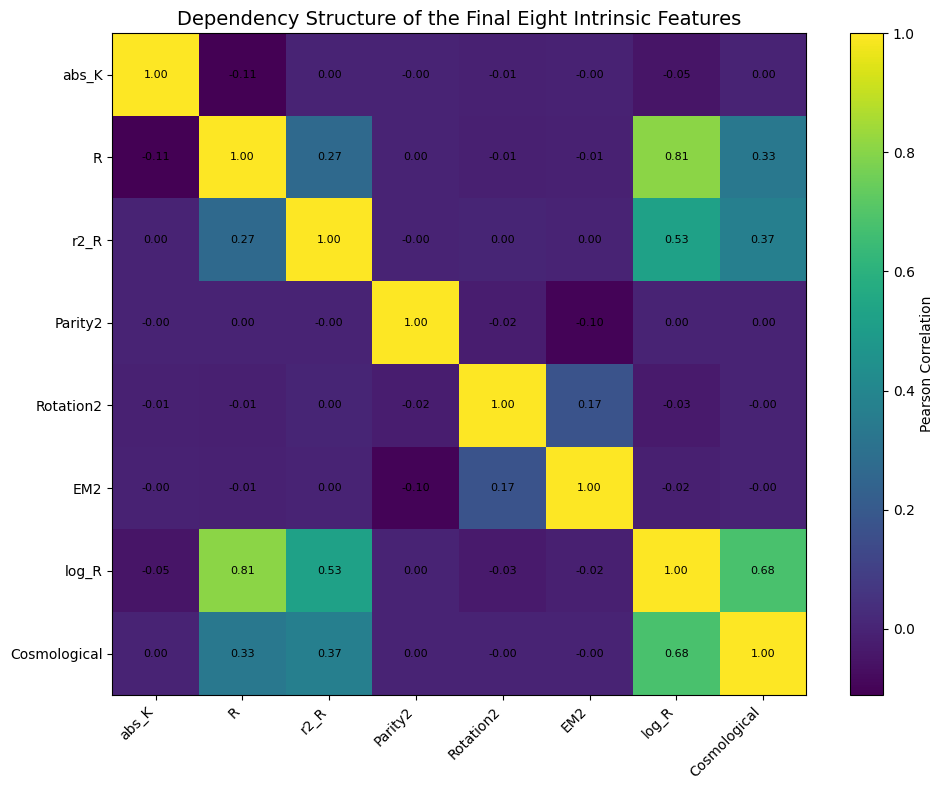


FIGURE 6
2D INTRINSIC SPACETIME-GEOMETRY MANIFOLD
UMAP time: 116.10 s


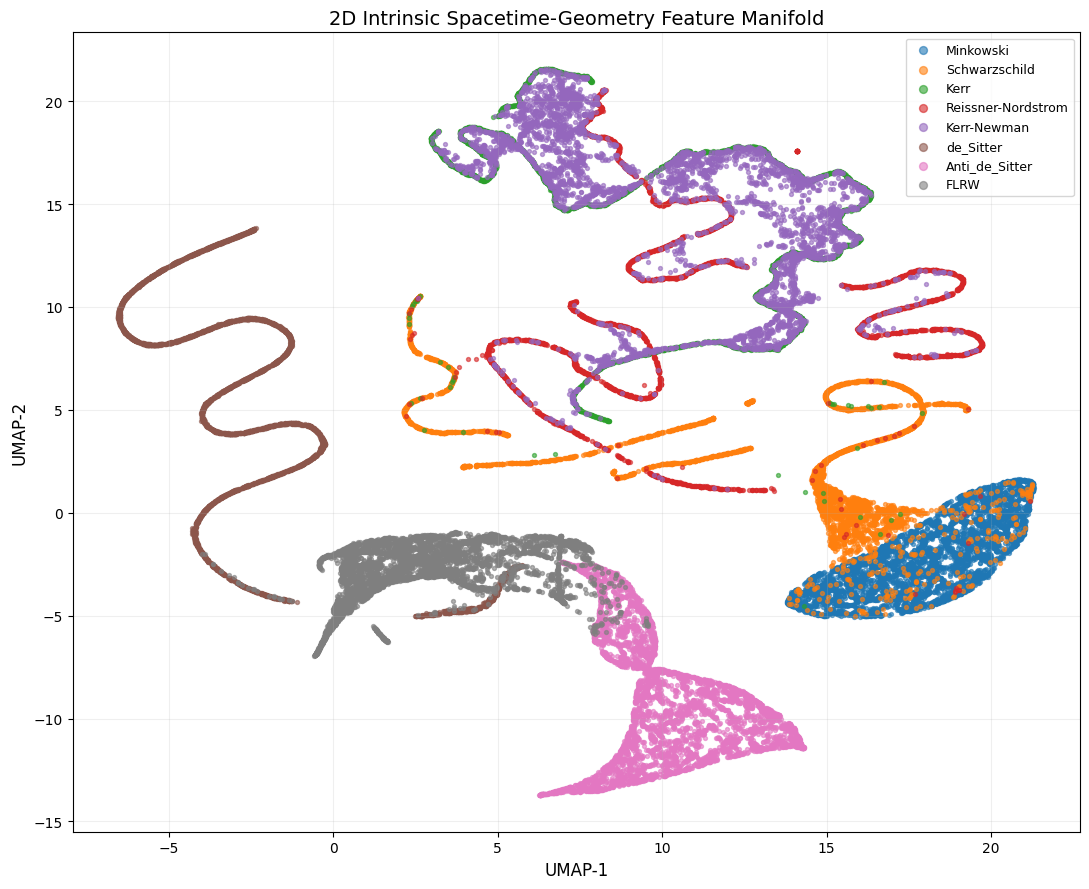


FIGURE 7
3D INTRINSIC SPACETIME-GEOMETRY MANIFOLD
UMAP time: 90.04 s


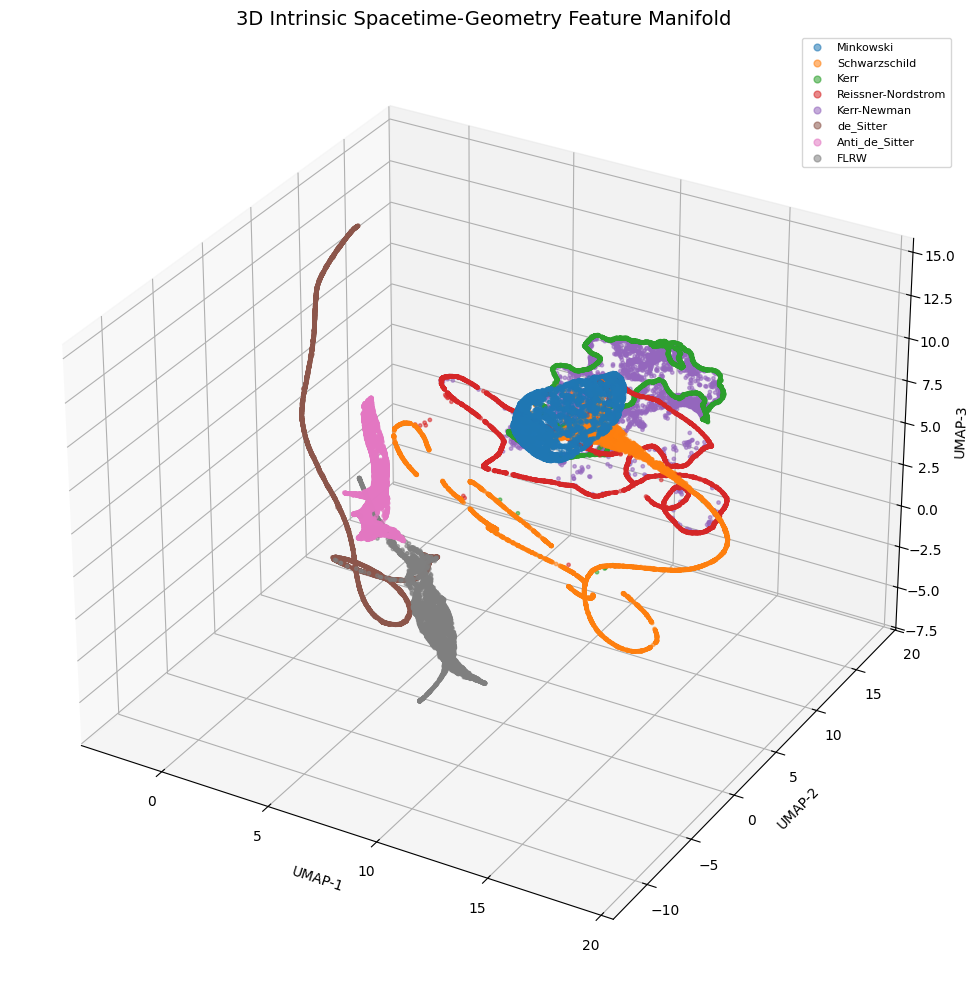


VISUALIZATION COMPLETE

Figures:
Figure 6: /content/GR_Spacetime_Dataset_V4/PAPER_FIGURES/Figure_6_2D_Intrinsic_Spacetime_Manifold.png
Figure 7: /content/GR_Spacetime_Dataset_V4/PAPER_FIGURES/Figure_7_3D_Intrinsic_Spacetime_Manifold.png
Figure 8: /content/GR_Spacetime_Dataset_V4/PAPER_FIGURES/Figure_8_8Feature_Correlation_Heatmap.png

✓ Test-set-only visualization completed.


In [ ]:

# ============================================================
# GR-SPACETIME V4
# FINAL 8-FEATURE INTRINSIC GEOMETRY VISUALIZATION
# ============================================================

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ============================================================
# PATHS
# ============================================================

BASE_DIR = "/content/GR_Spacetime_Dataset_V4"

DATA_FILE = os.path.join(
    BASE_DIR,
    "GR_Spacetime_V4_TEST.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "PAPER_FIGURES"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# FINAL 8 FEATURES
# ============================================================

FEATURES_8 = [
    "abs_K",
    "R",
    "r2_R",
    "Parity2",
    "Rotation2",
    "EM2",
    "log_R",
    "Cosmological"
]

TARGET = "label"

CLASS_NAMES = [
    "Minkowski",
    "Schwarzschild",
    "Kerr",
    "Reissner-Nordstrom",
    "Kerr-Newman",
    "de_Sitter",
    "Anti_de_Sitter",
    "FLRW"
]

SEED = 42

# ============================================================
# CHECK FILE
# ============================================================

print("=" * 80)
print("GR-SPACETIME V4")
print("FINAL 8-FEATURE INTRINSIC GEOMETRY VISUALIZATION")
print("=" * 80)

print("\nChecking dataset...")

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"\nDataset not found:\n{DATA_FILE}"
    )

print("✓ Test dataset found:")
print(DATA_FILE)

# ============================================================
# LOAD TEST DATA
# ============================================================

print("\nLoading test dataset...")

start = time.time()

df = pd.read_csv(DATA_FILE)

print(f"Dataset shape: {df.shape}")
print(f"Loading time : {time.time() - start:.2f} s")

# ============================================================
# VERIFY
# ============================================================

print("\n" + "=" * 80)
print("DATASET VERIFICATION")
print("=" * 80)

missing_features = [
    f for f in FEATURES_8
    if f not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing features: {missing_features}"
    )

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found."
    )

print("✓ All eight selected features detected.")
print("✓ Target column detected.")

# ============================================================
# EXTRACT FEATURES AND TARGET
# ============================================================

X = df[FEATURES_8].to_numpy(
    dtype=np.float64
)

y = df[TARGET].to_numpy(
    dtype=int
)

print("\nFeature matrix:", X.shape)
print("Target:", y.shape)

# ============================================================
# DATA QUALITY
# ============================================================

print("\n" + "=" * 80)
print("DATA QUALITY")
print("=" * 80)

print(
    "NaN:",
    np.isnan(X).sum()
)

print(
    "Inf:",
    np.isinf(X).sum()
)

if np.isnan(X).any() or np.isinf(X).any():
    raise ValueError(
        "NaN or Inf values detected."
    )

print("✓ Data quality passed.")

# ============================================================
# BALANCED VISUALIZATION SUBSET
# ============================================================
#
# Test set = 200,000 samples
# 25,000 samples per class
#
# For UMAP visualization we use:
# 5,000 samples per class = 40,000 total.
#
# This preserves equal representation of all
# eight spacetime geometries.
# ============================================================

N_PER_CLASS = 5000

rng = np.random.default_rng(SEED)

selected_indices = []

for class_id in range(8):

    indices = np.where(
        y == class_id
    )[0]

    print(
        f"{CLASS_NAMES[class_id]:20s}: "
        f"{len(indices):,} test samples"
    )

    selected = rng.choice(
        indices,
        size=N_PER_CLASS,
        replace=False
    )

    selected_indices.extend(
        selected
    )

selected_indices = np.array(
    selected_indices
)

rng.shuffle(
    selected_indices
)

X_vis = X[selected_indices]
y_vis = y[selected_indices]

print(
    f"\nVisualization dataset: "
    f"{len(y_vis):,} samples"
)

# ============================================================
# STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_vis
)

# ============================================================
# FIGURE 8
# 8-FEATURE CORRELATION HEATMAP
# ============================================================

print("\n" + "=" * 80)
print("FIGURE 8")
print("8-FEATURE DEPENDENCY HEATMAP")
print("=" * 80)

corr = pd.DataFrame(
    X_vis,
    columns=FEATURES_8
).corr()

fig, ax = plt.subplots(
    figsize=(10, 8)
)

im = ax.imshow(
    corr.values,
    interpolation="nearest",
    aspect="auto"
)

ax.set_xticks(
    np.arange(8)
)

ax.set_yticks(
    np.arange(8)
)

ax.set_xticklabels(
    FEATURES_8,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    FEATURES_8
)

ax.set_title(
    "Dependency Structure of the Final Eight Intrinsic Features",
    fontsize=14
)

cbar = fig.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "Pearson Correlation"
)

for i in range(8):
    for j in range(8):

        ax.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()

file8 = os.path.join(
    OUTPUT_DIR,
    "Figure_8_8Feature_Correlation_Heatmap.png"
)

plt.savefig(
    file8,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# INSTALL / IMPORT UMAP
# ============================================================

try:

    import umap

except ImportError:

    import subprocess
    import sys

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "umap-learn"
    ])

    import umap

# ============================================================
# FIGURE 6
# 2D UMAP
# ============================================================

print("\n" + "=" * 80)
print("FIGURE 6")
print("2D INTRINSIC SPACETIME-GEOMETRY MANIFOLD")
print("=" * 80)

start = time.time()

reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.10,
    metric="euclidean",
    random_state=SEED,
    n_jobs=1
)

embedding_2d = reducer_2d.fit_transform(
    X_scaled
)

print(
    f"UMAP time: "
    f"{time.time() - start:.2f} s"
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

for class_id, class_name in enumerate(
    CLASS_NAMES
):

    mask = y_vis == class_id

    ax.scatter(
        embedding_2d[mask, 0],
        embedding_2d[mask, 1],
        s=8,
        alpha=0.60,
        label=class_name,
        rasterized=True
    )

ax.set_xlabel(
    "UMAP-1",
    fontsize=12
)

ax.set_ylabel(
    "UMAP-2",
    fontsize=12
)

ax.set_title(
    "2D Intrinsic Spacetime-Geometry Feature Manifold",
    fontsize=14
)

ax.legend(
    fontsize=9,
    markerscale=2
)

ax.grid(
    alpha=0.2
)

plt.tight_layout()

file6 = os.path.join(
    OUTPUT_DIR,
    "Figure_6_2D_Intrinsic_Spacetime_Manifold.png"
)

plt.savefig(
    file6,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 7
# 3D UMAP
# ============================================================

print("\n" + "=" * 80)
print("FIGURE 7")
print("3D INTRINSIC SPACETIME-GEOMETRY MANIFOLD")
print("=" * 80)

start = time.time()

reducer_3d = umap.UMAP(
    n_components=3,
    n_neighbors=50,
    min_dist=0.10,
    metric="euclidean",
    random_state=SEED,
    n_jobs=1
)

embedding_3d = reducer_3d.fit_transform(
    X_scaled
)

print(
    f"UMAP time: "
    f"{time.time() - start:.2f} s"
)

fig = plt.figure(
    figsize=(12, 10)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

for class_id, class_name in enumerate(
    CLASS_NAMES
):

    mask = y_vis == class_id

    ax.scatter(
        embedding_3d[mask, 0],
        embedding_3d[mask, 1],
        embedding_3d[mask, 2],
        s=6,
        alpha=0.55,
        label=class_name,
        rasterized=True
    )

ax.set_xlabel(
    "UMAP-1"
)

ax.set_ylabel(
    "UMAP-2"
)

ax.set_zlabel(
    "UMAP-3"
)

ax.set_title(
    "3D Intrinsic Spacetime-Geometry Feature Manifold",
    fontsize=14
)

ax.legend(
    fontsize=8,
    markerscale=2
)

plt.tight_layout()

file7 = os.path.join(
    OUTPUT_DIR,
    "Figure_7_3D_Intrinsic_Spacetime_Manifold.png"
)

plt.savefig(
    file7,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# SAVE EMBEDDINGS
# ============================================================

embedding_df = pd.DataFrame({
    "UMAP1_2D": embedding_2d[:, 0],
    "UMAP2_2D": embedding_2d[:, 1],
    "UMAP1_3D": embedding_3d[:, 0],
    "UMAP2_3D": embedding_3d[:, 1],
    "UMAP3_3D": embedding_3d[:, 2],
    "label": y_vis
})

embedding_file = os.path.join(
    OUTPUT_DIR,
    "Intrinsic_Geometry_UMAP_Data.csv"
)

embedding_df.to_csv(
    embedding_file,
    index=False
)

# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 80)
print("VISUALIZATION COMPLETE")
print("=" * 80)

print("\nFigures:")

print(
    "Figure 6:",
    file6
)

print(
    "Figure 7:",
    file7
)

print(
    "Figure 8:",
    file8
)

print("\n✓ Test-set-only visualization completed.")